# 02 Data Understanding

In CRISP-DM Phase 2 beginnen wir mit der Datenverständ­nissanalyse. Dieser erste Abschnitt lädt den BRFSS-Datensatz aus dem UCI-Repository und prüft die grundlegende Struktur für die weitere EDA.

## 1. Setup
Installiere den UCI-ML-Repository-Client, falls er noch nicht verfügbar ist, und importiere anschließend alle benötigten Bibliotheken.

In [1]:
# Install ucimlrepo if running in a fresh environment
import importlib, subprocess, sys
if importlib.util.find_spec('ucimlrepo') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ucimlrepo'])


import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
from ucimlrepo import fetch_ucirepo

## 1. Datensatz laden 

Wir laden den Datensatz direkt aus dem UCI ML Repository über seine offizielle ID (891). Dadurch ist die Reproduzierbarkeit gewährleistet, ohne dass eine lokale CSV-Datei benötigt wird.

In [2]:
# Fetch dataset from UCI ML Repository
dataset = fetch_ucirepo(id=891)

X = dataset.data.features
y = dataset.data.targets

# Combine into a single DataFrame for convenience
df = pd.concat([X, y], axis=1)

print(f'Dataset loaded: {df.shape[0]:,}  × {df.shape[1]}')

Dataset loaded: 253,680  × 22


## 2. Grundstruktur

Bevor wir inhaltlich analysieren, verschaffen wir uns einen Überblick über Dimensionen, Datentypen und fehlende Werte — die drei grundlegendsten Qualitätsfragen bei jedem neuen Datensatz.

In [3]:
# --- Dimensionen ---
n_rows, n_cols = df.shape
print(f"Zeilen : {n_rows:,}")
print(f"Spalten: {n_cols}  (21 Features + 1 Target)\n")

# --- Features & Datentypen ---
dtype_map = df.dtypes.rename("dtype")
missing   = df.isnull().sum().rename("missing")
missing_pct = (missing / n_rows * 100).round(4).rename("missing_%")

summary = pd.concat([dtype_map, missing, missing_pct], axis=1)
print(summary.to_string())
print(f"\nGesamte fehlende Werte: {missing.sum()}")

Zeilen : 253,680
Spalten: 22  (21 Features + 1 Target)

                      dtype  missing  missing_%
HighBP                int64        0        0.0
HighChol              int64        0        0.0
CholCheck             int64        0        0.0
BMI                   int64        0        0.0
Smoker                int64        0        0.0
Stroke                int64        0        0.0
HeartDiseaseorAttack  int64        0        0.0
PhysActivity          int64        0        0.0
Fruits                int64        0        0.0
Veggies               int64        0        0.0
HvyAlcoholConsump     int64        0        0.0
AnyHealthcare         int64        0        0.0
NoDocbcCost           int64        0        0.0
GenHlth               int64        0        0.0
MentHlth              int64        0        0.0
PhysHlth              int64        0        0.0
DiffWalk              int64        0        0.0
Sex                   int64        0        0.0
Age                   int64     

## 3. Semantische Variablentypen

Nachdem die technische Grundstruktur des Datensatzes geprüft wurde, werden nun die inhaltlichen Variablentypen untersucht. Zwar sind alle Spalten als `int64` gespeichert, daraus lässt sich aber noch nicht ableiten, ob eine Variable tatsächlich numerisch, binär oder kategorial zu interpretieren ist.

Deshalb wird für jede Variable betrachtet, wie viele unterschiedliche Werte vorkommen und welche Wertebereiche vorliegen. Auf dieser Grundlage können die Merkmale anschließend sinnvoll in binäre Indikatoren, ordinale Kategorien und numerische beziehungsweise zählartige Variablen eingeordnet werden.

In [4]:
# All columns including the target variable
rows = []
for col in df.columns:
    n_unique = df[col].nunique()
    vals = sorted(df[col].unique().tolist())
    rows.append({
        "Variable":     col,
        "Rolle":        "Target" if col == "Diabetes_binary" else "Feature",
        "n_unique":     n_unique,
        "min":          df[col].min(),
        "max":          df[col].max(),
        "Ausprägungen": str(vals) if n_unique <= 15 else f"{vals[:5]} … {vals[-1]}",
    })

type_df = pd.DataFrame(rows).sort_values("n_unique")
print(type_df.to_string(index=False))

            Variable   Rolle  n_unique  min  max                                Ausprägungen
              HighBP Feature         2    0    1                                      [0, 1]
            HighChol Feature         2    0    1                                      [0, 1]
           CholCheck Feature         2    0    1                                      [0, 1]
              Smoker Feature         2    0    1                                      [0, 1]
HeartDiseaseorAttack Feature         2    0    1                                      [0, 1]
              Stroke Feature         2    0    1                                      [0, 1]
        PhysActivity Feature         2    0    1                                      [0, 1]
              Fruits Feature         2    0    1                                      [0, 1]
         NoDocbcCost Feature         2    0    1                                      [0, 1]
             Veggies Feature         2    0    1                      

Die Übersicht zeigt, dass die meisten Variablen binär kodiert sind. `HighBP`, `HighChol`, `CholCheck`, `Smoker`, `HeartDiseaseorAttack`, `Stroke`, `PhysActivity`, `Fruits`, `NoDocbcCost`, `Veggies`, `HvyAlcoholConsump`, `AnyHealthcare`, `Sex` und `DiffWalk` haben jeweils genau zwei Ausprägungen: 0 und 1. Sie zeigen an, ob ein bestimmtes Merkmal, Verhalten oder ein Gesundheitszustand vorliegt.

Neben diesen binären Features gibt es vier ordinal kodierte Merkmale: `GenHlth` (5 Stufen), `Education` (6 Stufen), `Income` (8 Stufen) und `Age` (13 Stufen). Die Reihenfolge der Werte trägt Informationen; die Abstände zwischen Kategorien sind nicht notwendig gleich groß.

`MentHlth` und `PhysHlth` nehmen Werte von 0 bis 30 an und bilden die Anzahl der beeinträchtigten Tage im letzten Monat ab — zählartige Merkmale mit einer Häufung bei 0. `BMI` weist mit 84 Ausprägungen und einem Bereich von 12 bis 98 die größte Spannweite auf und wird als numerisches Merkmal behandelt.

Das Target `Diabetes_binary` ist ebenfalls binär (0 = kein Diabetes, 1 = Prä-/Diabetes) mit den bereits bekannten Klassenverteilung (~86 % / ~14 %).

### 3.1 Variablenbeschreibungen

Die folgende Tabelle beschreibt die inhaltliche Bedeutung jeder Variable. Die Definitionen basieren auf den offiziellen BRFSS-2015-Fragebögen (CDC) und der UCI-Repository-Dokumentation.

| Variable | Rolle | Typ | Bedeutung |
|---|---|---|---|
| **Diabetes_binary** | **Target** | binary | 0 = kein Diabetes, 1 = Prä-/Diabetes (Ever told)  |
| HighBP | Feature | binary | 0 = kein Bluthochdruck, 1 = Bluthochdruck diagnostiziert |
| HighChol | Feature | binary | 0 = kein erhöhter Cholesterinwert, 1 = erhöhter Wert diagnostiziert |
| CholCheck | Feature | binary | 0 = kein Cholesterin-Check in den letzten 5 Jahren, 1 = Check erfolgt |
| Smoker | Feature | binary | 0 = nein, 1 = mind. 100 Zigaretten im Leben geraucht |
| Stroke | Feature | binary | 0 = kein Schlaganfall, 1 = jemals Schlaganfall gehabt (Ever told) |
| HeartDiseaseorAttack | Feature | binary | 0 = keine, 1 = koronare Herzerkrankung oder Herzinfarkt |
| PhysActivity | Feature | binary | 0 = nein, 1 = körperl. Aktivität in den letzten 30 Tagen (nicht beruflich) |
| Fruits | Feature | binary | 0 = nein, 1 = Obst ≥ 1× täglich |
| Veggies | Feature | binary | 0 = nein, 1 = Gemüse ≥ 1× täglich |
| HvyAlcoholConsump | Feature | binary | 0 = nein, 1 = starker Alkoholkonsum (Männer ≥14, Frauen ≥7 Drinks/Woche) |
| AnyHealthcare | Feature | binary | 0 = keine, 1 = irgendeine Krankenversicherung vorhanden |
| NoDocbcCost | Feature | binary | 0 = nein, 1 = Arztbesuch trotz Bedarf aus Kostengründen unterblieben |
| DiffWalk | Feature | binary | 0 = nein, 1 = erhebliche Schwierigkeiten beim Gehen oder Treppensteigen |
| Sex | Feature | binary | 0 = weiblich, 1 = männlich |
| GenHlth | Feature | ordinal | Allgemeiner Gesundheitszustand: 1 = ausgezeichnet, 2=sehr gut, 3=gut, 4= in Ordnung, 5 = schlecht |
| Age | Feature | ordinal | Alterskategorie: 1 = 18–24 J., 2 = 25–29 J., …, 13 = ≥ 80 J. (je ~5 Jahre) |
| Education | Feature | ordinal | Bildungsgrad: 1 = nie Schule/nur Kindergarten, 2 = Klassenstufen 1–8, 3 = Klassenstufen 9–11, 4 = Klassenstufe 12 oder GED/High-School-Abschluss, 5 = 1–3 Jahre College/technische Schule, 6 = 4 Jahre College oder mehr/College-Abschluss |
| Income | Feature | ordinal | Haushaltseinkommen: 1 = < $10 000 … 8 = ≥ $75 000 |
| MentHlth | Feature | count | Tage mit eingeschränkter psychischer Gesundheit in den letzten 30 Tagen (0–30) |
| PhysHlth | Feature | count | Tage mit körperlicher Erkrankung oder Verletzung in den letzten 30 Tagen (0–30) |
| BMI | Feature | numeric | Body-Mass-Index (ganzzahlig gerundet; Wertebereich 12–98) |

## 4. Verteilung der Zielvariable

Bevor wir mit der Feature-Analyse beginnen, schauen wir uns die Verteilung des Targets `Diabetes_binary` an.

=== Klassenverteilung ===
  0 – Kein Diabetes           218,334  (86.1 %)
  1 – Prä-/Diabetes            35,346  (13.9 %)

  Gesamt: 253,680


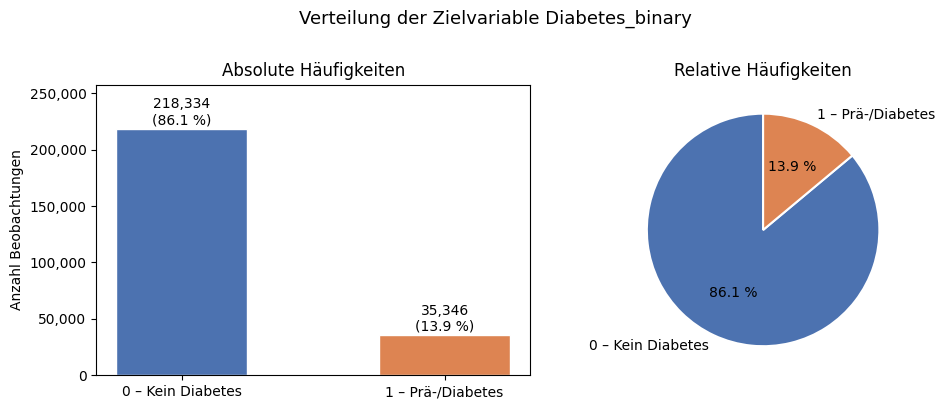

In [5]:
counts = df["Diabetes_binary"].value_counts().sort_index()
labels = ["0 – Kein Diabetes", "1 – Prä-/Diabetes"]

print("=== Klassenverteilung ===")
for n, lbl in zip(counts, labels):
    print(f"  {lbl:<26}  {n:>7,}  ({n/counts.sum()*100:.1f} %)")
print(f"\n  Gesamt: {counts.sum():,}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, counts.values, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
for i, (n, pct) in enumerate(zip(counts.values, counts.values / counts.sum() * 100)):
    axes[0].text(i, n + 1500, f"{n:,}\n({pct:.1f} %)", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Absolute Häufigkeiten", fontsize=12)
axes[0].set_ylabel("Anzahl Beobachtungen")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_ylim(0, counts[0] * 1.18)

axes[1].pie(
    counts.values,
    labels=labels,
    autopct="%1.1f %%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Relative Häufigkeiten", fontsize=12)

plt.suptitle("Verteilung der Zielvariable Diabetes_binary", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Die Zielvariable `Diabetes_binary` ist deutlich ungleich verteilt. Von insgesamt 253.680 Beobachtungen gehören 218.334 Personen zur Klasse 0, also zur Gruppe ohne Diabetes. Das entspricht 86,1 % des Datensatzes. Die Klasse 1, also Prädiabetes/Diabetes, umfasst 35.346 Personen und macht damit nur 13,9 % der Beobachtungen aus.

Damit liegt ein deutliches Klassenungleichgewicht vor. Für die spätere Modellierung bedeutet das, dass Accuracy allein keine geeignete Hauptmetrik ist, da ein Modell bereits durch überwiegende Vorhersage der Mehrheitsklasse hohe Accuracy-Werte erreichen könnte. Für dieses Projekt sind daher Metriken wichtiger, die die Minderheitsklasse stärker berücksichtigen, insbesondere PR-AUC beziehungsweise Average Precision sowie Recall, Precision und F1-Score.

Die Klassenverteilung bestätigt außerdem, dass das Projekt als imbalanced binary classification problem behandelt werden sollte.

## 5. Duplikat- und Label-Konsistenz-Analyse

BRFSS ist eine telefonische Querschnittsbefragung — jede Person sollte genau einmal erfasst sein. Dennoch können identische Zeilen aus zwei Quellen stammen: echte Wiederholungsteilnahme (selten) oder doppelter Eintrag bei der Datenbankbereinigung. Darüber hinaus interessiert uns, ob es Feature-Vektoren gibt, die mit widersprüchlichen Labels auftauchen: gleiche Merkmalskombination, aber unterschiedlicher Diabetes-Status. Das wäre ein direktes empirisches Maß für irreduzibles Label-Rauschen — Rauschen, das kein Modell beseitigen kann, weil es in den Daten selbst kodiert ist.

Wir unterscheiden daher:
- **Exakte Duplikate** — identische Zeile in *allen* 22 Spalten einschließlich Target
- **Feature-Duplikate mit Labelkonflikt** — gleicher 21-dimensionaler Feature-Vektor, aber unterschiedliches `Diabetes_binary`

In [6]:
feature_cols = [c for c in df.columns if c != "Diabetes_binary"]

# --- Exakte Duplikate (alle 22 Spalten) ---
exact_dups = df.duplicated(keep=False)
n_exact_rows = exact_dups.sum()
n_exact_groups = df[exact_dups].groupby(df.columns.tolist()).ngroups

print("=== Exakte Duplikate ===")
print(f"  Betroffene Zeilen : {n_exact_rows:>7,}  ({n_exact_rows/len(df)*100:.2f} %)")
print(f"  Eindeutige Gruppen: {n_exact_groups:>7,}")

# --- Feature-Duplikate mit Labelkonflikt ---
# Group by all 21 features; keep groups that have >1 unique label value
label_per_vector = (
    df.groupby(feature_cols)["Diabetes_binary"]
    .agg(["nunique", "count", "mean"])
    .reset_index()
)
conflict_groups = label_per_vector[label_per_vector["nunique"] > 1]
n_conflict_rows = conflict_groups["count"].sum()
n_conflict_groups = len(conflict_groups)

print("\n=== Feature-Duplikate mit Labelkonflikt ===")
print(f"  Betroffene Zeilen  : {n_conflict_rows:>7,}  ({n_conflict_rows/len(df)*100:.2f} %)")
print(f"  Eindeutige Vektoren: {n_conflict_groups:>7,}")

# Irreduzibles Rauschen: Anteil der Minority-Labels innerhalb jeder Konfliktgruppe
# Für jede Konfliktgruppe ist min(p, 1-p) der nicht erklärbaren Anteil
noise_per_group = conflict_groups["mean"].apply(lambda p: min(p, 1 - p))
irreducible_noise_rows = (noise_per_group * conflict_groups["count"]).sum()
noise_rate = irreducible_noise_rows / len(df)

print(f"\n=== Empirisches irreduzibles Rauschen ===")
print(f"  Geschätzte betroffene Zeilen: {irreducible_noise_rows:>8,.0f}  ({noise_rate*100:.2f} %)")

=== Exakte Duplikate ===
  Betroffene Zeilen :  35,575  (14.02 %)
  Eindeutige Gruppen:  11,369

=== Feature-Duplikate mit Labelkonflikt ===
  Betroffene Zeilen  :   5,218  (2.06 %)
  Eindeutige Vektoren:   1,566

=== Empirisches irreduzibles Rauschen ===
  Geschätzte betroffene Zeilen:    1,640  (0.65 %)


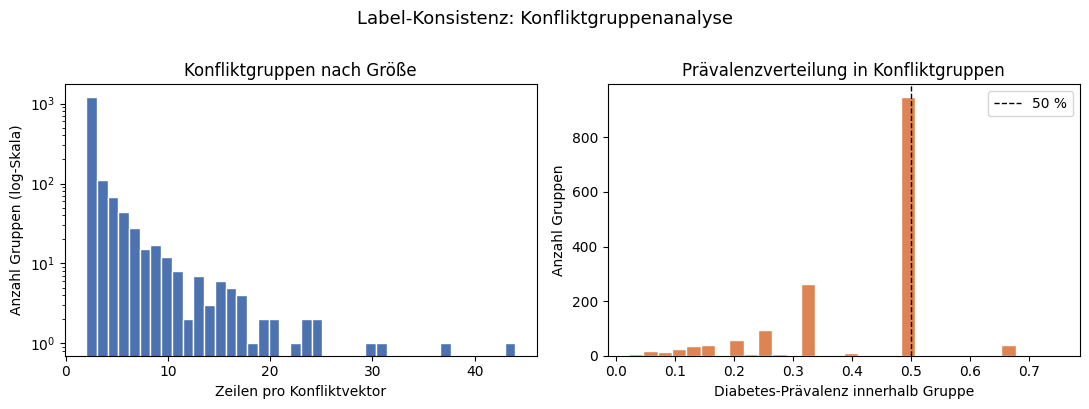

In [7]:
# Distribution of conflict group sizes (how many rows share the same conflicting vector)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: histogram of conflict-group sizes
axes[0].hist(conflict_groups["count"], bins=40, color="#4C72B0", edgecolor="white", log=True)
axes[0].set_xlabel("Zeilen pro Konfliktvektor")
axes[0].set_ylabel("Anzahl Gruppen (log-Skala)")
axes[0].set_title("Konfliktgruppen nach Größe")

# Right: distribution of Diabetes prevalence within conflict groups
axes[1].hist(conflict_groups["mean"], bins=30, color="#DD8452", edgecolor="white")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1, label="50 %")
axes[1].set_xlabel("Diabetes-Prävalenz innerhalb Gruppe")
axes[1].set_ylabel("Anzahl Gruppen")
axes[1].set_title("Prävalenzverteilung in Konfliktgruppen")
axes[1].legend()

plt.suptitle("Label-Konsistenz: Konfliktgruppenanalyse", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation

**Exakte Duplikate** entstehen, wenn Zeilen in allen 22 Spalten (Features *und* Target) übereinstimmen. Bei telefonischen Surveys wie BRFSS sind sie unvermeidbar, da viele Befragte dieselbe Kombination von Merkmalsausprägungen aufweisen; sie sind kein Hinweis auf Datenbankfehler und werden *nicht* entfernt.

Der aus den Konfliktgruppen geschätzte **beobachtbare Konfliktanteil** (~0,65 % der Zeilen) ist eine **empirische untere Schranke**: Er gibt an, wie viele Zeilen selbst bei einem theoretisch perfekten Modell auf Basis dieses Feature-Sets nicht konsistent klassifiziert werden können. Dieser Wert entspricht dem, was in , Section 4, konzeptuell als Label-Noise hergeleitet wurde — er ist nun empirisch quantifizierbar, aber nicht als harte Fehlergrenze zu verstehen: Nicht alle Konflikte sind auf irreduzibles Rauschen zurückzuführen, ein Teil kann auch auf seltene, aber reale Feature-Kombinationen entfallen.

Für die Modellierung bedeutet das: Recall-Constraints (z. B. Recall ≥ 0,80) müssen mit Blick auf diesen Konfliktanteil kalibriert werden. Ein Modell kann in Konfliktregionen des Feature-Raums strukturell nicht besser als zufällig werden.

### Interpretation: Label-Konsistenz-Analyse

Die Konfliktgruppen sind fast ausnahmslos klein (2–3 Zeilen), was auf zufälliges Rauschen
hinweist, nicht auf systematische Kodierungsfehler. Der dominante Peak bei einer
Gruppen-Prävalenz von 0,5 (ca. 900 Gruppen) zeigt, dass die Mehrzahl der Konflikte
einfache Paare sind: ein identischer Feature-Vektor erhält einmal Label 0 und einmal Label 1.

Die Verteilung ist asymmetrisch: Gruppen mit Prävalenz < 0,5 überwiegen gegenüber solchen > 0,5. Das heißt, in Konfliktfällen tendiert das Label zur 0 (kein Diabetes). Das stützt die
Hypothese aus dem Business Understanding — nicht diagnostizierte oder nicht gemeldete
Diabetes-Fälle werden als negativ kodiert (FN-Bias), nicht umgekehrt.

Der geschätzte beobachtbare Konfliktanteil (~0,65 % der Zeilen) dient als empirische untere Schranke. Diese Zahl wird in der Evaluationsphase als Interpretationshilfe herangezogen — sie ist kein exakter Bayes-Fehler, sondern ein beobachtbares Minimum aus den Konflikten im vorliegenden Feature-Set.

## 6. Allgemeine Feature-Verteilungen

Bevor wir die Features in Bezug auf das Target analysieren, schauen wir uns ihre Marginalverteilungen an. Das dient zwei Zwecken: Auffällige Verteilungen (z. B. stark rechtsschiefe Zählvariablen, Ausreißer bei BMI) können auf Erfassungsartefakte hinweisen; und die Basisraten der binären Features helfen zu beurteilen, ob seltene Ausprägungen ein späteres Modellierungsproblem darstellen.

### 6.1 Binäre Features

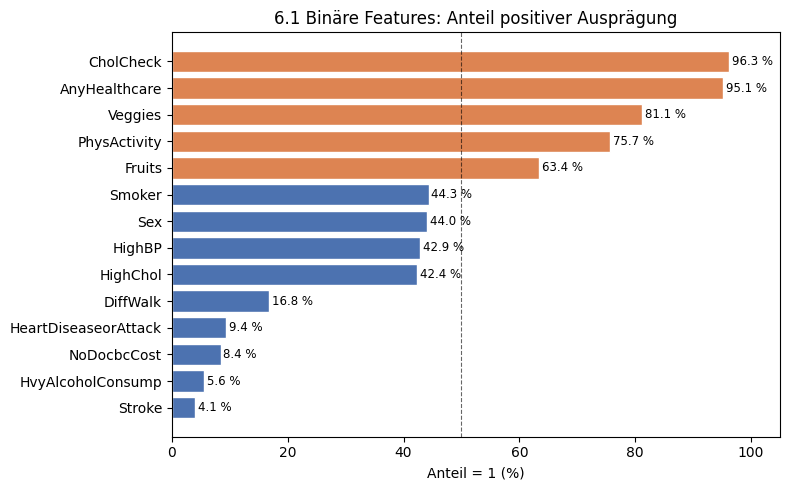

In [8]:
# Feature-Gruppen einmalig definieren — werden in Abschnitten 6 und 7 wiederverwendet
BINARY_COLS  = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
                "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
                "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]
ORDINAL_COLS = ["GenHlth", "Age", "Education", "Income"]
COUNT_COLS   = ["MentHlth", "PhysHlth"]
NUMERIC_COLS = ["BMI"]

# Anteil positiver Ausprägung (= 1) pro binärem Feature
prev_bin = df[BINARY_COLS].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0" if v < 0.5 else "#DD8452" for v in prev_bin.values]
bars = ax.barh(prev_bin.index, prev_bin.values * 100, color=colors, edgecolor="white")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, prev_bin.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val*100:.1f} %", va="center", fontsize=8.5)
ax.set_xlabel("Anteil = 1 (%)")
ax.set_xlim(0, 105)
ax.set_title("6.1 Binäre Features: Anteil positiver Ausprägung", fontsize=12)
plt.tight_layout()
plt.show()

Der Plot zeigt den Anteil positiver Ausprägungen (= 1) für alle 14 binären Features,
sortiert nach Häufigkeit.

**Auffällig wenig Varianz:** `CholCheck` (96,3 %) und `AnyHealthcare` (95,1 %) sind
nahezu konstant. Features mit fast ausschließlich einer Ausprägung tragen wenig
zur Trennung der Klassen bei — ihr Informationsgehalt ist gering, unabhängig von
ihrer inhaltlichen Plausibilität.

**Gute Varianz:** `HighBP` (42,9 %), `HighChol` (42,4 %), `Smoker` (44,3 %) und
`Sex` (44,0 %) liegen nahe 50/50 und sind damit potenziell informativer für das Modell.

**Seltene Ereignisse:** `Stroke` (4,1 %), `HvyAlcoholConsump` (5,6 %),
`NoDocbcCost` (8,4 %) und `HeartDiseaseorAttack` (9,4 %) sind selten.
Ob sie trotz niedriger Basisrate prädiktiv für Diabetes sind, zeigt erst die
bivariate Analyse (Abschnitt 5).

Die univariate Verteilung allein erlaubt noch keine Aussage zur Vorhersagekraft —
ein Feature kann selten und dennoch stark prädiktiv sein, wenn es innerhalb der
positiven Klasse deutlich überrepräsentiert ist.

### 6.2 Ordinale Features

`GenHlth`, `Age`, `Education` und `Income` sind ordinal kodiert; die Abstände zwischen Kategorien sind inhaltlich nicht gleichwertig. Die Häufigkeitsverteilung zeigt, ob einzelne Kategorien so selten sind, dass sie Modellierungsprobleme verursachen könnten.

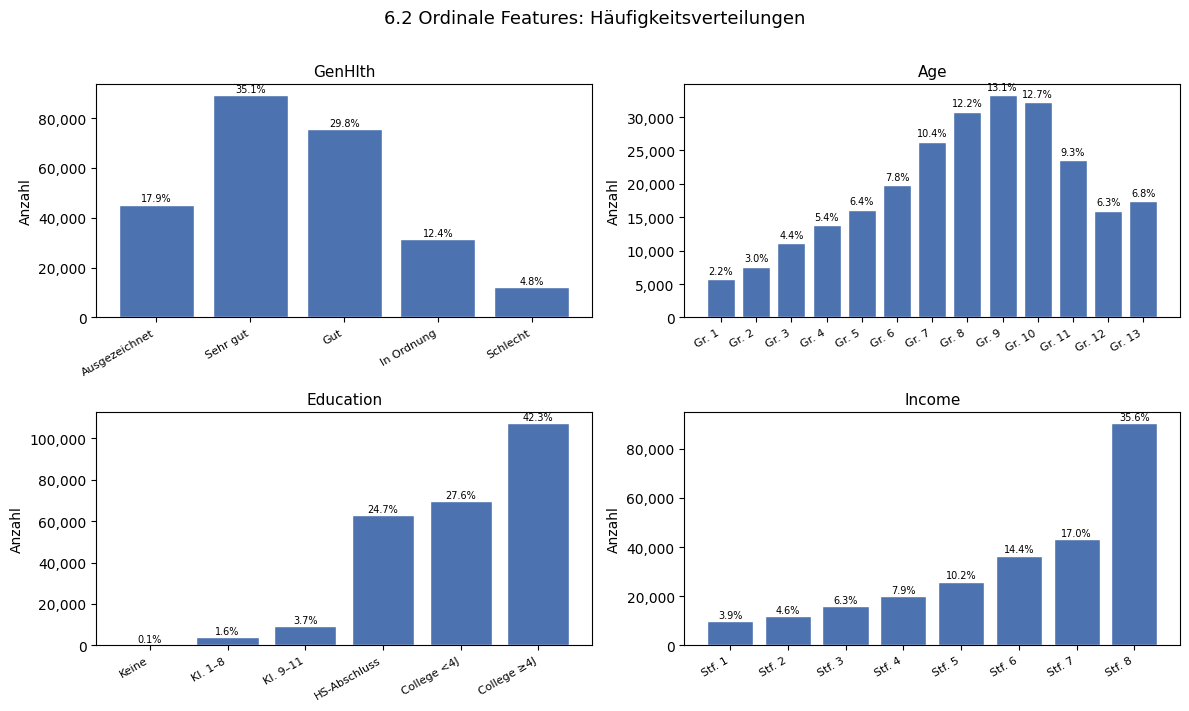

In [9]:
ordinal_labels = {
    "GenHlth":   {1: "Ausgezeichnet", 2: "Sehr gut", 3: "Gut", 4: "In Ordnung", 5: "Schlecht"},
    "Age":       {i: f"Gr. {i}" for i in range(1, 14)},
    "Education": {1: "Keine", 2: "Kl. 1–8", 3: "Kl. 9–11", 4: "HS-Abschluss", 5: "College <4J", 6: "College ≥4J"},
    "Income":    {i: f"Stf. {i}" for i in range(1, 9)},
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, col in zip(axes, ORDINAL_COLS):
    counts = df[col].value_counts().sort_index()
    labels = [ordinal_labels[col].get(k, str(k)) for k in counts.index]
    bars = ax.bar(range(len(counts)), counts.values, color="#4C72B0", edgecolor="white")
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Anzahl")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f"{n/len(df)*100:.1f}%", ha="center", va="bottom", fontsize=7)

plt.suptitle("6.2 Ordinale Features: Häufigkeitsverteilungen", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**GenHlth** ist gut über alle fünf Stufen verteilt, mit Schwerpunkt auf „Sehr gut"
(35,1 %) und „Gut" (29,8 %). Nur 4,8 % berichten schlechten Gesundheitszustand.
Die Verteilung ist leicht links-schief (Tendenz zu positiver Selbsteinschätzung),
bietet aber ausreichend Varianz für eine gute Trennkraft — GenHlth gilt als einer
der stärksten Prädiktoren für chronische Erkrankungen in BRFSS-basierten Studien.

**Age** zeigt eine annähernd glockenförmige Verteilung mit Peak in den mittleren
Altersgruppen (Gr. 9–10, entspricht ca. 60–69 Jahre). Jüngere Gruppen (Gr. 1–3)
sind unterrepräsentiert, was typisch für Telefon-Surveys ist. Da das Diabetesrisiko
mit dem Alter steigt, ist eine starke bivariate Assoziation zu erwarten.

**Education** ist stark rechts-schief: 42,3 % haben einen Hochschulabschluss
(College ≥ 4 Jahre), die unteren Bildungsstufen machen zusammen unter 6 % aus.
Der Deckeneffekt am oberen Ende schränkt die Varianz ein — ein bekanntes
Selektionsproblem bei Telefon-Surveys (BRFSS erfasst bildungsfernere Schichten
systematisch seltener).

**Income** zeigt dasselbe Muster: Stufe 8 (höchstes Einkommen) dominiert mit
35,6 %. Die Verteilung ist keine Normalverteilung, sondern monoton steigend.
Auch hier liegt ein Survey-Selektionsbias vor. Trotzdem ist Income inhaltlich
relevant, da niedrigeres Einkommen mit schlechterem Versorgungszugang und
höherem Diabetesrisiko assoziiert ist.

**Konsequenz:** Education und Income haben durch den Deckeneffekt eingeschränkte
Varianz an den unteren Ausprägungen. Ob das die Vorhersagekraft beeinträchtigt,
zeigt die bivariate Analyse.

### 6.3 Count- und numerische Features

`MentHlth` und `PhysHlth` sind Zählvariablen (0–30 Tage); beide werden erfahrungsgemäß stark bei 0 gehueft sein. `BMI` ist ganzzahlig gerundet und kann im Extrembereich Erfassungsartefakte enthalten.

BMI  — Median: 27  |  P1: 18  |  P99: 50  |  Extremwerte (außerhalb P1/P99): 3,499 (1.38 %)
MentHlth — 0-Anteil: 69.3 %  |  30-Anteil: 4.8 %  |  Median: 0
PhysHlth — 0-Anteil: 63.1 %  |  30-Anteil: 7.6 %  |  Median: 0


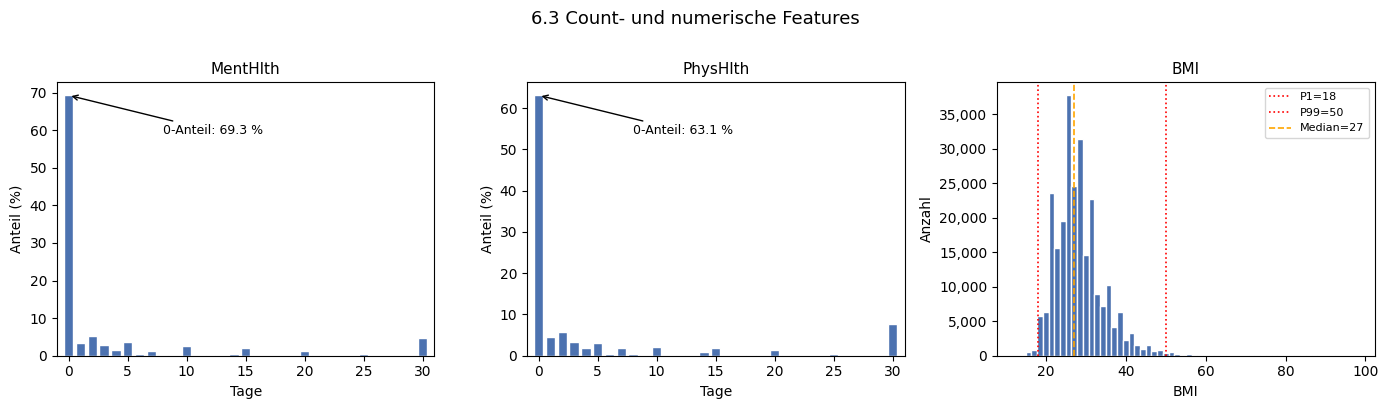

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# MentHlth & PhysHlth: bar chart (discrete 0–30)
for ax, col in zip(axes[:2], COUNT_COLS):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values / len(df) * 100, color="#4C72B0", edgecolor="white", width=0.8)
    zero_pct = df[col].eq(0).mean() * 100
    ax.annotate(f"0-Anteil: {zero_pct:.1f} %", xy=(0, counts[0] / len(df) * 100),
                xytext=(8, counts[0] / len(df) * 100 * 0.85),
                arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Tage")
    ax.set_ylabel("Anteil (%)")
    ax.set_xlim(-1, 31)

# BMI: histogram + summary stats
ax = axes[2]
ax.hist(df["BMI"], bins=60, color="#4C72B0", edgecolor="white")
for pct, ls in [(1, ":"), (99, ":")]:
    v = np.percentile(df["BMI"], pct)
    ax.axvline(v, color="red", linestyle=ls, linewidth=1.2, label=f"P{pct}={v:.0f}")
ax.axvline(df["BMI"].median(), color="orange", linestyle="--", linewidth=1.2,
           label=f"Median={df['BMI'].median():.0f}")
ax.set_title("BMI", fontsize=11)
ax.set_xlabel("BMI")
ax.set_ylabel("Anzahl")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=8)

# Extremwerte
bmi_p1, bmi_p99 = np.percentile(df["BMI"], [1, 99])
n_extreme = df["BMI"].gt(bmi_p99).sum() + df["BMI"].lt(bmi_p1).sum()
print(f"BMI  — Median: {df['BMI'].median():.0f}  |  P1: {bmi_p1:.0f}  |  P99: {bmi_p99:.0f}  "
      f"|  Extremwerte (außerhalb P1/P99): {n_extreme:,} ({n_extreme/len(df)*100:.2f} %)")
for col in COUNT_COLS:
    print(f"{col} — 0-Anteil: {df[col].eq(0).mean()*100:.1f} %  |  "
          f"30-Anteil: {df[col].eq(30).mean()*100:.1f} %  |  Median: {df[col].median():.0f}")

plt.suptitle("6.3 Count- und numerische Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**MentHlth und PhysHlth** sind zero-inflated Count-Variablen (Tage mit schlechter
Gesundheit in den letzten 30 Tagen). Bei beiden dominiert 0 stark: 69,3 % bzw.
63,1 % der Befragten berichten keine einzigen schlechten Tag — der Median liegt
jeweils bei 0. Gleichzeitig gibt es einen zweiten kleinen Peak bei 30 Tagen
(4,8 % bzw. 7,6 %), was auf einen Survey-Anker-Effekt hindeutet: Befragte mit
dauerhafter Beeinträchtigung wählen „30" als Proxy für „immer". Die bimodale
Struktur (0 und 30 dominieren, dazwischen wenig) ist kein Messfehler, sondern
eine bekannte Eigenschaft von BRFSS-Gesundheitsfragen. Für baumbasierte Modelle
ist diese Verteilung unproblematisch; für lineare Modelle wäre eine Transformation
nötig.

**BMI** ist rechts-schief mit Median 27 (Grenze Normalgewicht/Übergewicht nach WHO).
Der Bereich P1–P99 liegt zwischen 18 und 50, 1,38 % der Werte liegen außerhalb
(3.499 Zeilen). Die Ausreißer sind fast ausschließlich nach oben gerichtet — extreme
Adipositas ist im Datensatz vorhanden, Untergewicht kaum. BMI-Werte über 60 sind
physiologisch möglich aber selten; ein Capping auf P99 (= 50) wird in Phase 3 als
Option geprüft. Der Median von 27 liegt im Übergewichtsbereich, was der realen
US-Bevölkerungsverteilung entspricht und keinen Qualitätsfehler darstellt.

**Konsequenz für Phase 3:** MentHlth und PhysHlth werden as-is weiterverwendet
(baumbasierte Modelle tolerieren zero-inflation). BMI-Extremwerte werden in der
Datenaufbereitung auf Capping vs. Behalten entschieden.

## 7. Feature-Target-Zusammenhänge

Jetzt verbinden wir die Marginalverteilungen mit dem Target. Ziel ist es, zu quantifizieren, welche Features besonders stark mit `Diabetes_binary` assoziiert sind — rein deskriptiv, ohne Kausalaussage. Diese Analyse informiert die spätere Feature-Selection und hilft, die Ergebnisse des Modells einzuordnen.

### 7.1 Diabetes-Prävalenz je binärem Feature

Für jedes binäre Feature berechnen wir die Diabetes-Rate getrennt für den negativen (= 0) und positiven (= 1) Ausprägungswert. Der Unterschied (Δ) zwischen beiden zeigt, wie stark das Feature mit dem Target assoziiert ist.

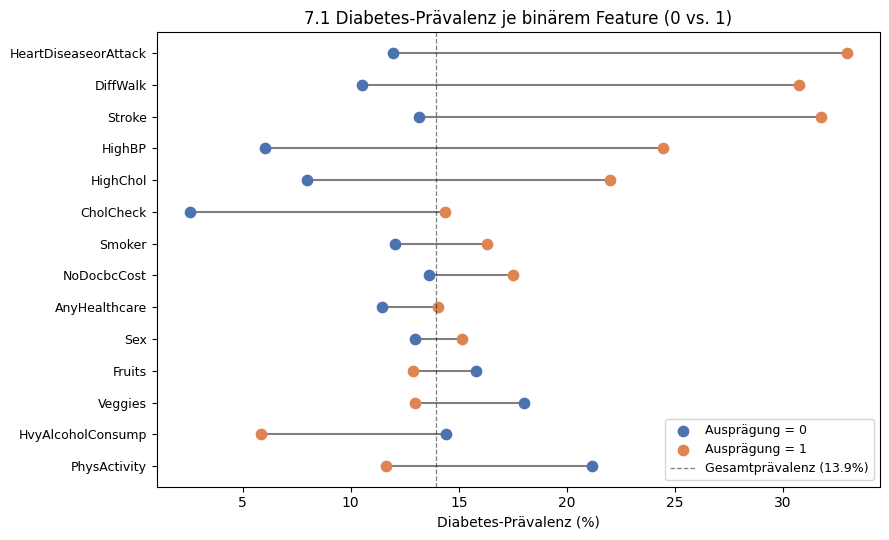


Δ-Ranking (größter Unterschied zuerst):
             Feature Prävalenz (=0) Prävalenz (=1)      Δ
HeartDiseaseorAttack          12.0%          33.0% +21.0%
            DiffWalk          10.5%          30.7% +20.2%
              Stroke          13.2%          31.8% +18.6%
              HighBP           6.0%          24.4% +18.4%
            HighChol           8.0%          22.0% +14.0%
           CholCheck           2.5%          14.4% +11.8%
              Smoker          12.1%          16.3%  +4.2%
         NoDocbcCost          13.6%          17.5%  +3.9%
       AnyHealthcare          11.5%          14.1%  +2.6%
                 Sex          13.0%          15.2%  +2.2%
              Fruits          15.8%          12.9%  -2.9%
             Veggies          18.0%          13.0%  -5.0%
   HvyAlcoholConsump          14.4%           5.8%  -8.6%
        PhysActivity          21.1%          11.6%  -9.5%


In [11]:
rows = []
for col in BINARY_COLS:
    p0 = df.loc[df[col] == 0, "Diabetes_binary"].mean()
    p1 = df.loc[df[col] == 1, "Diabetes_binary"].mean()
    rows.append({"Feature": col, "Prävalenz (=0)": p0, "Prävalenz (=1)": p1, "Δ": p1 - p0})

assoc_df = pd.DataFrame(rows).sort_values("Δ")

fig, ax = plt.subplots(figsize=(9, 5.5))
y = range(len(assoc_df))

ax.hlines(y, assoc_df["Prävalenz (=0)"] * 100, assoc_df["Prävalenz (=1)"] * 100,
          color="gray", linewidth=1.5, zorder=1)
ax.scatter(assoc_df["Prävalenz (=0)"] * 100, y, color="#4C72B0", s=55, zorder=2, label="Ausprägung = 0")
ax.scatter(assoc_df["Prävalenz (=1)"] * 100, y, color="#DD8452", s=55, zorder=2, label="Ausprägung = 1")
ax.axvline(df["Diabetes_binary"].mean() * 100, color="black", linestyle="--",
           linewidth=0.9, alpha=0.5, label=f"Gesamtprävalenz ({df['Diabetes_binary'].mean()*100:.1f}%)")

ax.set_yticks(list(y))
ax.set_yticklabels(assoc_df["Feature"], fontsize=9)
ax.set_xlabel("Diabetes-Prävalenz (%)")
ax.set_title("7.1 Diabetes-Prävalenz je binärem Feature (0 vs. 1)", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nΔ-Ranking (größter Unterschied zuerst):")
print(assoc_df.sort_values("Δ", ascending=False)
      .assign(**{"Prävalenz (=0)": lambda d: d["Prävalenz (=0)"].map("{:.1%}".format),
                 "Prävalenz (=1)": lambda d: d["Prävalenz (=1)"].map("{:.1%}".format),
                 "Δ": lambda d: d["Δ"].map("{:+.1%}".format)})
      .to_string(index=False))

Der Plot zeigt die Diabetes-Prävalenz getrennt nach Feature-Ausprägung (0 vs. 1),
sortiert nach dem absoluten Prävalenzunterschied Δ.

**Stärkste positive Prädiktoren (Δ > 10 %):**
HeartDiseaseorAttack (+21 %), DiffWalk (+20,2 %), Stroke (+18,6 %) und HighBP
(+18,4 %) zeigen die größten Unterschiede. Das ist inhaltlich plausibel — diese
Variablen bilden einen klassischen Komorbiditäts-Cluster: kardiovaskuläre
Erkrankungen, Bluthochdruck und eingeschränkte Mobilität sind bekannte Begleit-
und Folgeerkrankungen von Typ-2-Diabetes. **Stroke und HeartDiseaseorAttack sind
dabei als Komorbiditätsmarker zu interpretieren — nicht als frühe Risikofaktoren.**
Sie zeigen an, dass bereits ein hohes Krankheitsniveau besteht, und verschieben
die Modellinterpretation von Früherkennung hin zur Risikobewertung bestehender
Hochrisikoprofile. HighChol (+14 %) und CholCheck (+11,8 %) ergänzen diesen Cluster.

**CholCheck als Diagnose-Proxy:** Wer keinen Cholesterin-Check hatte (= 0), zeigt
nur 2,5 % Diabetes-Prävalenz — der niedrigste Wert aller Features. Das ist kein
protektiver Effekt, sondern Diagnose-Bias: ohne Arztbesuch keine Diabetes-Diagnose.
CholCheck misst teilweise Inanspruchnahme medizinischer Versorgung, nicht nur
Cholesterin-Status.

**Schwache positive Prädiktoren (Δ < 5 %):** Smoker, NoDocbcCost, AnyHealthcare
und Sex zeigen nur geringe Unterschiede. Ihr bivariater Signal ist schwach; ob sie
nach Kontrolle für Alter und Komorbidität noch erklären, zeigt das Modell.

**Negative Prädiktoren:** PhysActivity (−9,5 %) und HvyAlcoholConsump (−8,6 %)
sind assoziiert mit niedrigerer Diabetes-Prävalenz. PhysActivity ist erwartbar.
HvyAlcoholConsump ist kontraintuitiv — eine mögliche Erklärung ist Survivorship-
oder Healthy-User-Bias: Diabetiker reduzieren Alkohol nach Diagnose, oder starke
Trinker sind im Schnitt jünger. Dieser Befund ist nicht kausal zu interpretieren.

**Einschränkung:** Alle Δ-Werte sind bivariate, nicht für Confounding bereinigte
Assoziationen. Alter, Einkommen und GenHlth sind potenzielle Confounder, die in
der Modellierung über die gemeinsame Feature-Matrix kontrolliert werden.

### 7.2 Gruppenvergleich bei ordinalen und numerischen Features

Bei den ordinalen Features schauen wir uns die Diabetes-Prävalenz per Kategorie als Linienverlauf an — ein monotoner Anstieg (oder Abfall) wäre ein Hinweis auf eine geordnete Beziehung, die Tree-basierte Modelle ohne Encoding erfassen können. Für `BMI`, `MentHlth` und `PhysHlth` vergleichen wir die Klassenverteilungen über KDE-Plots.

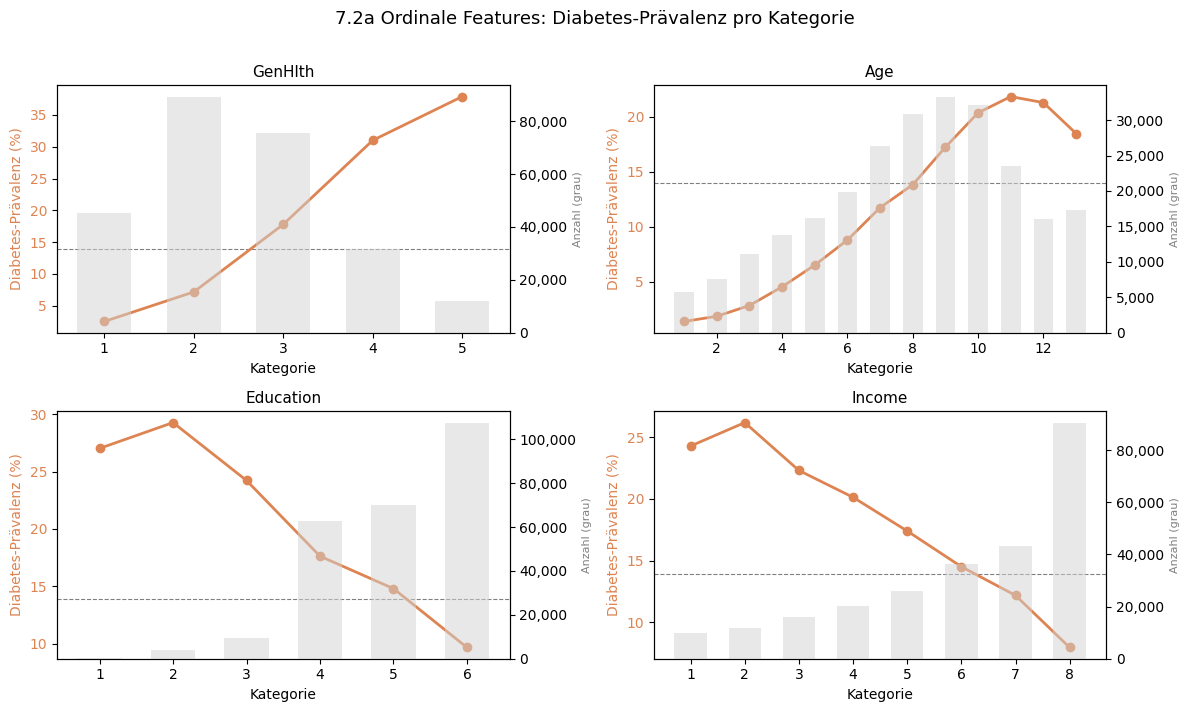

In [12]:
# --- Ordinale Features: Prävalenz per Kategorie ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, col in zip(axes, ORDINAL_COLS):
    prev = df.groupby(col)["Diabetes_binary"].mean() * 100
    n_per_cat = df[col].value_counts().sort_index()
    
    color_bars = [plt.cm.Blues(0.35 + 0.5 * (i / (len(prev) - 1))) for i in range(len(prev))]
    ax2 = ax.twinx()
    ax2.bar(prev.index, n_per_cat.reindex(prev.index), color="lightgray", alpha=0.5, width=0.6, zorder=0)
    ax2.set_ylabel("Anzahl (grau)", fontsize=8, color="gray")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    
    ax.plot(prev.index, prev.values, marker="o", color="#DD8452", linewidth=2, zorder=3)
    ax.axhline(df["Diabetes_binary"].mean() * 100, color="black", linestyle="--",
               linewidth=0.8, alpha=0.5)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Kategorie")
    ax.set_ylabel("Diabetes-Prävalenz (%)", color="#DD8452")
    ax.tick_params(axis="y", labelcolor="#DD8452")

plt.suptitle("7.2a Ordinale Features: Diabetes-Prävalenz pro Kategorie", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Alle vier ordinalen Features zeigen weitgehend geordnete Zusammenhänge zwischen
Kategorie und Diabetes-Prävalenz — mit einzelnen Ausnahmen, die inhaltlich
erklärbar sind.

**GenHlth** zeigt den stärksten und gleichmäßigsten Anstieg aller Features: von
~4 % Prävalenz bei „Ausgezeichnet" (Kat. 1) bis ~37 % bei „Schlecht" (Kat. 5).
Die Kurve überschreitet die Gesamtprävalenz (13,9 %) bereits bei Kat. 3 („Gut").
GenHlth ist damit bivariat der stärkste Einzelprädiktor im Datensatz.

**Age** steigt von ~2 % (jüngste Gruppe) bis ~21 % (Gr. 11–12), fällt dann aber
leicht in Gr. 13 (älteste Gruppe) ab. Dieser Rückgang ist plausibel durch einen
Survivorship-Effekt: die älteste Kohorte enthält überproportional gesunde
Überlebende; schwer Erkrankte sind seltener in Telefonsurveys erreichbar.

**Education** zeigt einen inversen Zusammenhang: niedrige Bildung (Kat. 1–2)
~27–29 %, höchste Bildung (Kat. 6) ~10 %. Kat. 2 liegt leicht über Kat. 1,
was jedoch wegen der sehr kleinen Stichprobe in Kat. 1 (nur 0,1 % der Daten)
nicht überinterpretiert werden sollte.

**Income** fällt nahezu gleichmäßig von ~24–26 % bei niedrigstem Einkommen auf
~9 % bei höchstem — der klarste inverse Zusammenhang unter den vier Features.

**Gemeinsame Schlussfolgerung:** Die geordneten Zusammenhänge stützen die
ordinale Kodierung. One-Hot-Encoding würde die inhaltliche Reihenfolge der
Kategorien zerstören. Die Entscheidung zur Kodierung wird in Phase 3 festgelegt.

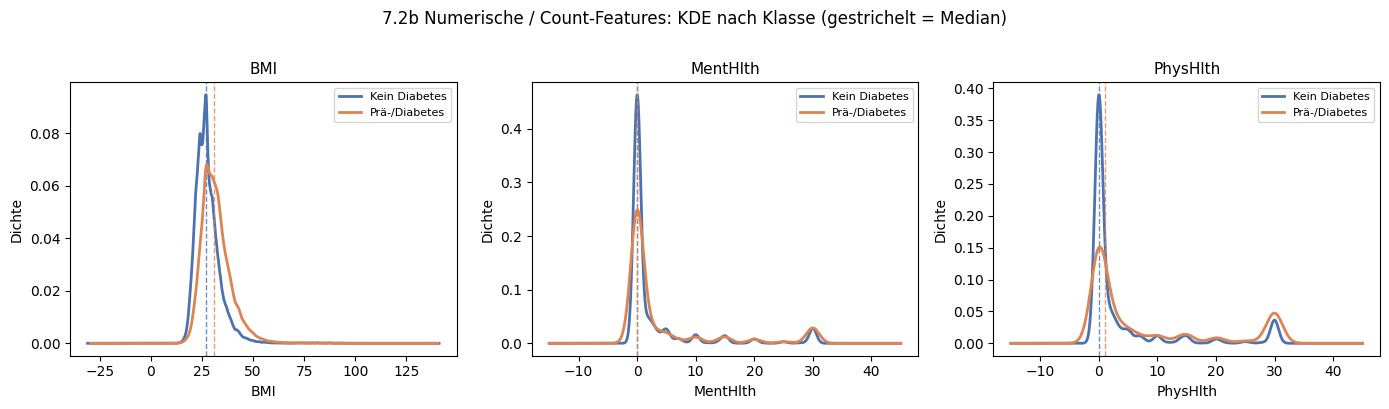

Medianvergleich (Diabetes=0 vs. Diabetes=1):
  BMI           kein Diabetes: 27.0   Diabetes: 31.0   Δ=+4.0
  MentHlth      kein Diabetes: 0.0   Diabetes: 0.0   Δ=+0.0
  PhysHlth      kein Diabetes: 0.0   Diabetes: 1.0   Δ=+1.0


In [13]:
# --- Numerische / Count-Features: KDE split by class ---
palette = {0: "#4C72B0", 1: "#DD8452"}
labels_map = {0: "Kein Diabetes", 1: "Prä-/Diabetes"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, NUMERIC_COLS + COUNT_COLS):
    for cls in [0, 1]:
        subset = df.loc[df["Diabetes_binary"] == cls, col]
        subset.plot.kde(ax=ax, color=palette[cls], linewidth=2, label=labels_map[cls])
        ax.axvline(subset.median(), color=palette[cls], linestyle="--", linewidth=1, alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=8)

plt.suptitle("7.2b Numerische / Count-Features: KDE nach Klasse (gestrichelt = Median)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Medianvergleich
print("Medianvergleich (Diabetes=0 vs. Diabetes=1):")
for col in NUMERIC_COLS + COUNT_COLS:
    m0 = df.loc[df["Diabetes_binary"] == 0, col].median()
    m1 = df.loc[df["Diabetes_binary"] == 1, col].median()
    print(f"  {col:<12}  kein Diabetes: {m0:.1f}   Diabetes: {m1:.1f}   Δ={m1-m0:+.1f}")

**BMI** zeigt den deutlichsten Klassenunterschied der drei Features. Die Verteilung
der Diabetes-Gruppe (orange) ist gegenüber der Nicht-Diabetes-Gruppe (blau) nach
rechts verschoben — der Median liegt bei Prä-/Diabetes bei 31, bei Kein Diabetes
bei 27 (Δ = +4). Zudem ist die Kurve der Diabetes-Gruppe flacher und breiter, was
auf mehr Streuung bei höheren BMI-Werten hindeutet. BMI ist damit bivariat ein
relevanter Prädiktor, was mit dem bekannten Zusammenhang zwischen Adipositas und
Typ-2-Diabetes übereinstimmt.

**MentHlth** zeigt keinen Klassenunterschied — beide Mediane liegen bei 0,
Δ = 0. Die Kurven sind nahezu identisch. MentHlth ist bivariat kein relevantes
Signal. Auffällig sind kleine Nebenmaxima bei runden Zahlen (5, 10, 15, 20, 30)
— ein bekanntes Befragungs-Artefakt: Personen runden ihre Antworten auf
5er- und 10er-Werte (Rounding Bias).

**PhysHlth** liegt dazwischen: Median Kein Diabetes = 0, Diabetes = 1 (Δ = +1).
Der Unterschied ist gering, im KDE aber sichtbar — die Diabetes-Gruppe hat einen
etwas niedrigeren Peak bei 0 und einen etwas höheren Anteil bei 30 Tagen.
Auch hier ist der Rounding Bias erkennbar.

## 8. Multivariate Analyse: Spearman-Rangkorrelation

Für eine vollständige Korrelationsanalyse eines gemischten Datensatzes (binär, ordinal, count, numerisch) eignet sich Spearmans ρ besser als Pearsons r: Es setzt keine Normalverteilung voraus, ist robust gegenüber Ausreißern und erfasst monotone, nicht notwendig lineare Zusammenhänge. Da alle Features als ganzzahlige Codes vorliegen, kann `scipy.stats.spearmanr` direkt auf dem gesamten DataFrame angewendet werden.

Wir betrachten drei Perspektiven:

1. **Heatmap aller Features + Target** — Überblick über die gesamte Korrelationsstruktur  
2. **Top-10 Feature ↔ Target** — stärkste Prädiktoren nach |ρ|  
3. **Top-15 Inter-Feature-Paare (ohne Target)** — stärkste Redundanzen / Kollinearitäten

### 8.1 Vollständige Korrelationsmatrix (Heatmap)

Die bivariate Analyse in Abschnitt 7 hat Features einzeln gegen das Target untersucht.
Hier betrachten wir alle 22 Spalten gleichzeitig: Welche Features korrelieren nicht nur
mit dem Target, sondern auch untereinander? Erst das Gesamtbild zeigt Cluster redundanter
Variablen und potenzielle Multikollinearität — beides ist für Feature Selection und
Regularisierung in den Phasen 3 und 4 relevant.

**Warum Spearman und nicht Pearson?**

Pearson misst lineare Zusammenhänge und setzt Intervallskalenniveau voraus — d.h. gleich
große Abstände zwischen allen Werten. Das ist hier für die meisten Features nicht erfüllt:

| Gruppe | Features | Problem mit Pearson |
|---|---|---|
| Binär (14x) | HighBP, HighChol, … | Nur zwei Werte, keine Abstände |
| Ordinal (4x) | GenHlth, Age, Education, Income | Geordnet, aber Abstände nicht gleich groß |
| Count (2x) | MentHlth, PhysHlth | Zero-inflated, stark rechtsschief |
| Numerisch (1x) | BMI | Rechtsschief, Extremwerte |

Spearman arbeitet stattdessen mit **Rängen**: Jeder Wert wird durch seinen Rang in der
sortierten Liste ersetzt, bevor korreliert wird. Dadurch ist Spearman:

- **Skalenniveau-agnostisch**: gültig für ordinale, binäre und numerische Variablen
- **Robust**: Ausreißer (z.B. BMI=98) verändern nur ihren Rang, nicht das
  Korrelationsergebnis
- **Monoton statt linear**: erfasst auch nichtlineare Zusammenhänge, sofern sie
  gleichförmig steigend oder fallend sind

Für rein binäre Variablenpaare liefert Spearman dasselbe Ergebnis wie Pearson — es
entsteht kein Informationsverlust.

Die untere Dreiecksmatrix genügt, da ρ(A,B) = ρ(B,A) gilt.

**Farbskala:** vmin/vmax auf ±0.5 gesetzt, da bei diesem Datensatz keine Korrelation
diesen Bereich nennenswert überschreitet. Die volle Skala (±1) würde alle relevanten
Unterschiede in einem schmalen Farbband zusammenpressen.

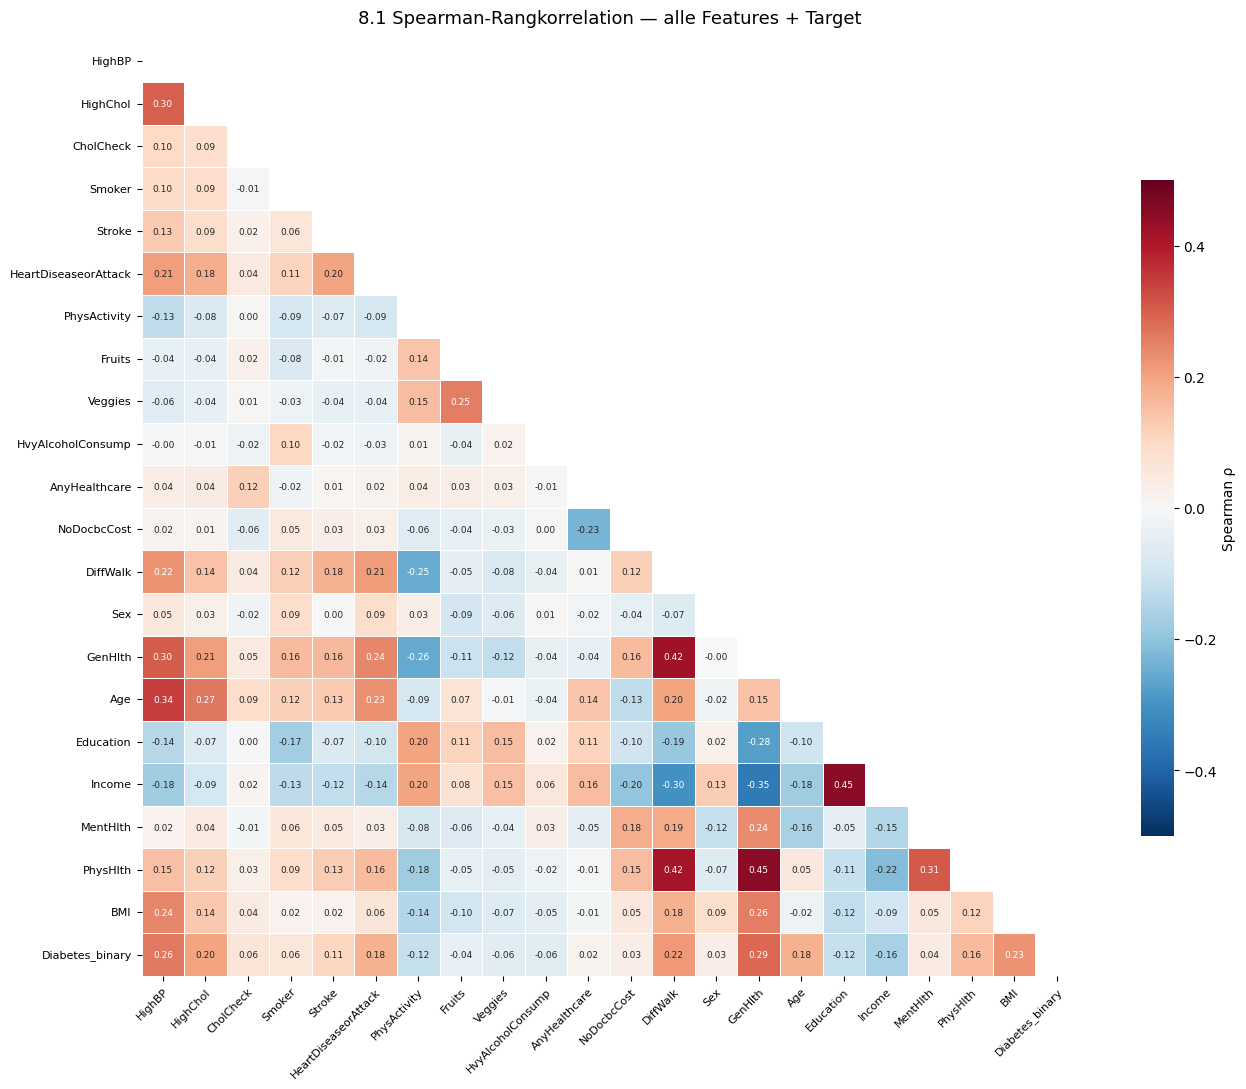

In [14]:
# Spearman-Korrelationsmatrix über alle 22 Spalten (21 Features + Target)
# spearmanr gibt ein (n,n)-Array zurück; wir konvertieren es in einen DataFrame
col_order = BINARY_COLS + ORDINAL_COLS + COUNT_COLS + NUMERIC_COLS + ["Diabetes_binary"]
df_ordered = df[col_order]

corr_matrix, _ = stats.spearmanr(df_ordered)
corr_df = pd.DataFrame(corr_matrix, index=col_order, columns=col_order)

mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_df,
    mask=mask,
    cmap="RdBu_r",
    vmin=-0.5, vmax=0.5,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6.5},
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Spearman ρ"},
    ax=ax,
)
ax.set_title("8.1 Spearman-Rangkorrelation — alle Features + Target", fontsize=13, pad=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=8)
ax.tick_params(axis="y", labelsize=8, rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:**

**1. Keine schwere Multikollinearität**
Kein Feature-Paar überschreitet |ρ| = 0.5. Die stärksten Inter-Feature-Korrelationen
liegen bei Income × Education (ρ = 0.45) und PhysHlth × GenHlth (ρ = 0.45), gefolgt
von GenHlth × DiffWalk (ρ = 0.42) und PhysHlth × DiffWalk (ρ = 0.42). Für tree-basierte
Modelle ist das irrelevant; für die Logistic-Regression-Baseline ist ein VIF-Check in
Phase 3 dennoch empfohlen, da mehrere moderate Korrelationen kumulativ zu instabilen
Koeffizienten führen können.

**2. Drei strukturelle Cluster**

*Cardiovascular-Cluster:* HighBP × HighChol (ρ = 0.30), HighBP × HeartDiseaseorAttack
(ρ = 0.21), Stroke × HeartDiseaseorAttack (ρ = 0.20), Age × HighBP (ρ = 0.34),
Age × HighChol (ρ = 0.27). Diese Variablen messen verwandte kardiometabolische
Zustände und korrelieren alle positiv mit dem Target (ρ = 0.18–0.26). Konsistent mit
der Definition des metabolischen Syndroms (Alberti et al., 2009) und motiviert ein
Composite-Feature in Phase 3.

*Physical-Health-Cluster:* GenHlth × PhysHlth (ρ = 0.45), GenHlth × DiffWalk (ρ = 0.42),
PhysHlth × DiffWalk (ρ = 0.42), PhysHlth × MentHlth (ρ = 0.31). Diese Features messen
körperliche und subjektive Einschränkungen aus unterschiedlichen Perspektiven (subjektive
Gesundheit, schlechte Tage, Gehschwierigkeiten) und stellen die stärksten Einzelprädiktoren
für Diabetes (ρ = 0.22–0.29).

*Sozioökonomischer Cluster:* Income × Education (ρ = 0.45), Income × GenHlth (ρ = −0.35),
Income × NoDocbcCost (ρ = −0.30), Income × DiffWalk (ρ = −0.30). Höheres Einkommen und
mehr Bildung gehen mit besserer Gesundheit und geringerer Diabetes-Prävalenz einher
(ρ = −0.12 bis −0.16). Konsistent mit der epidemiologischen Literatur zu sozialen
Determinanten von Diabetes (Agardh et al., 2011).

**3. Bestätigung schwacher Features**

CholCheck (max |ρ| = 0.12) und AnyHealthcare (max |ρ| = 0.23, jedoch nur mit NoDocbcCost)
zeigen keine substanziellen Zusammenhänge mit dem Target (ρ = 0.06 bzw. 0.02). Der
Befund schwach-konstanter Verteilung aus Abschnitt 6.1 wird hier multivariat bestätigt:
Beide Features sind plausible Drop-Kandidaten für Phase 3.

**4. Erwartungswidrige Befunde**

MentHlth korreliert kaum mit dem Target (ρ = 0.04), obwohl die bivariate Analyse in
Abschnitt 7 eine sichtbare — wenn auch schwache — Prävalenz-Differenz gezeigt hat.
Spearman erfasst monotone Zusammenhänge; bei zero-inflated Verteilungen (69 % Nullen)
verteilt sich die Information ungleichmäßig auf die Ränge, was den globalen
Korrelationskoeffizienten dämpft. Phase 3 wird MentHlth daher als Hurdle-Encoding
behandeln (Indikator + Wert), um den möglichen Effekt sauberer zu separieren.

HvyAlcoholConsump korreliert schwach negativ mit dem Target (ρ = −0.06). Wie in
Abschnitt 7 diskutiert, ist das kein protektiver Effekt, sondern Selektionsbias —
Personen mit schwerwiegenden chronischen Erkrankungen konsumieren weniger Alkohol.
Der Befund wird nicht kausal interpretiert.

**Konsequenzen für Phase 3:**
- Cardiovascular-Composite aus HighBP, HighChol, HeartDiseaseorAttack, Stroke
- Physical-Health-Composite aus GenHlth, PhysHlth, DiffWalk
- Sozioökonomischen Composite aus Income + Education prüfen
- VIF-Check vor Logistic Regression
- MentHlth als Hurdle-Encoding: `MentHlth_any` (0/1) + `MentHlth_days` (Wert wenn > 0)
- CholCheck und AnyHealthcare als Drop-Kandidaten markieren (Entscheidung nach
  Feature-Importance-Vergleich in Phase 4)

### 8.2 Top-10 Features nach Korrelation mit dem Target

Die Heatmap in 8.1 zeigt alle paarweisen Zusammenhänge gleichzeitig — für die
Identifikation der wichtigsten Einzelprädiktoren ist eine fokussierte Darstellung
nützlicher. Wir extrahieren die zehn Features mit der höchsten absoluten Spearman-Korrelation
zum Target und visualisieren sie inklusive Vorzeichen.

Diese Liste dient später als Vergleichsmaßstab für modellbasierte Feature-Importance
(XGBoost Gain, Permutation Importance): Stimmen die datenbasierten Top-Prädiktoren mit
denen überein, die das Modell tatsächlich nutzt, ist das ein Validitätshinweis. Größere
Abweichungen wären erklärungsbedürftig — etwa durch nichtlineare Interaktionen, die
Spearman nicht erfasst.

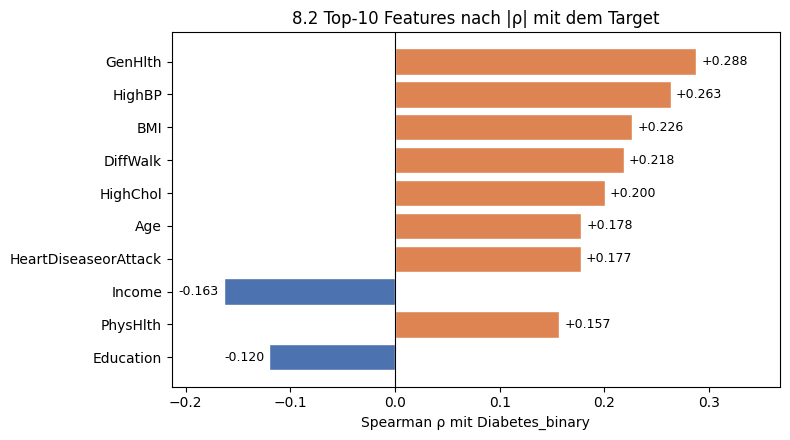

Top-10 Feature ↔ Target (Spearman ρ):
                             ρ       |ρ|
GenHlth               0.287697  0.287697
HighBP                0.263129  0.263129
BMI                   0.226314  0.226314
DiffWalk              0.218344  0.218344
HighChol              0.200276  0.200276
Age                   0.177684  0.177684
HeartDiseaseorAttack  0.177282  0.177282
Income               -0.163305  0.163305
PhysHlth              0.156752  0.156752
Education            -0.120038  0.120038


In [15]:
# --- 8.2 Top-10 Feature ↔ Target (nach |ρ|) ---
target_corr = (
    corr_df["Diabetes_binary"]
    .drop("Diabetes_binary")
    .rename("rho")
    .to_frame()
    .assign(abs_rho=lambda d: d["rho"].abs())
    .sort_values("abs_rho", ascending=False)
)

top10 = target_corr.head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#DD8452" if r > 0 else "#4C72B0" for r in top10["rho"]]
bars = ax.barh(top10.index[::-1], top10["rho"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, top10["rho"][::-1]):
    xpos = val + (0.005 if val >= 0 else -0.005)
    ha = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2, f"{val:+.3f}", va="center", ha=ha, fontsize=9)
ax.set_xlabel("Spearman ρ mit Diabetes_binary")
ax.set_title("8.2 Top-10 Features nach |ρ| mit dem Target", fontsize=12)
ax.set_xlim(
    min(top10["rho"].min() - 0.05, -0.05),
    max(top10["rho"].max() + 0.08, 0.05)
)
plt.tight_layout()
plt.show()

print("Top-10 Feature ↔ Target (Spearman ρ):")
print(top10[["rho", "abs_rho"]].rename(columns={"rho": "ρ", "abs_rho": "|ρ|"}).to_string())

**Interpretation:**

**Stärke der Zusammenhänge.** Alle zehn Top-Korrelationen liegen im Bereich
|ρ| = 0.12–0.29 — also schwach bis moderat. Kein einzelnes Feature dominiert die
Vorhersage; Diabetes-Status erklärt sich aus dem **Zusammenspiel mehrerer Variablen**.
Das ist konsistent mit der Erwartung an einen multifaktoriellen Krankheitsprozess und
spricht systematisch für nichtlineare Modelle, die Feature-Interaktionen erfassen
(XGBoost, Random Forest), gegenüber rein additiven Ansätzen.

**Inhaltliche Hierarchie.** Die fünf stärksten Prädiktoren bilden einen klar
interpretierbaren Kern:

1. **GenHlth** (ρ = +0.288) — subjektiv schlechte Gesundheit, stärkster Einzelprädiktor
2. **HighBP** (ρ = +0.263) — Bluthochdruck, klassischer kardiometabolischer Marker
3. **BMI** (ρ = +0.226) — Übergewicht/Adipositas, etablierter Hauptrisikofaktor
4. **DiffWalk** (ρ = +0.218) — Mobilitätseinschränkung, Folgesymptom oder Komorbidität
5. **HighChol** (ρ = +0.200) — Cholesterinprobleme, Teil des metabolischen Clusters

Diese Reihenfolge deckt sich exakt mit den Befunden aus der bivariaten Analyse
(Abschnitt 7) und mit der epidemiologischen Literatur zu Typ-2-Diabetes-Risikofaktoren.

**Schutzfaktoren.** Mit Income (ρ = −0.163) und Education (ρ = −0.120) erscheinen zwei
sozioökonomische Variablen im Top-10. Das Vorzeichen wird nicht kausal interpretiert,
sondern bestätigt den in Abschnitt 8.1 beschriebenen sozioökonomischen Gradienten:
höheres Einkommen und mehr Bildung sind mit besserer Gesundheit und geringerer
Diabetes-Prävalenz assoziiert.

**Was fehlt im Top-10.** Bemerkenswert ist die **Abwesenheit von Verhaltensvariablen**
wie PhysActivity, Smoker, Fruits, Veggies und HvyAlcoholConsump. Diese liegen alle
unter |ρ| = 0.13. Verhaltens-Features sind im BRFSS-Datensatz also deutlich schwächere
Prädiktoren als somatische Marker und sozioökonomische Variablen. Eine plausible
Erklärung: Selbstberichtetes Verhalten ist mit erheblichem Recall- und Sozial-Desirability-Bias
behaftet, während Diagnosen (HighBP, HighChol) klinisch verifizierbar sind. Phase 4 wird
prüfen, ob Verhaltens-Features in Kombination (z. B. als Lifestyle-Composite) dennoch
Vorhersagekraft liefern.

**Konsequenzen für die spätere Modellierung:**
- Die fünf Top-Prädiktoren werden als **Referenz** für Modell-Feature-Importance in Phase 4 dienen.
- Da kein Feature |ρ| > 0.3 erreicht, ist eine reine Single-Feature-Heuristik nicht
  ausreichend — multivariate Modelle sind methodisch zwingend.
- Sozioökonomische Variablen (Income, Education) gehören in das finale Feature-Set,
  auch wenn ihr individueller Beitrag moderat erscheint.

### 8.3 Stärkste Inter-Feature-Korrelationen

Die Heatmap in 8.1 zeigt alle Feature-Beziehungen flächig — für die Identifikation
struktureller Cluster und potenzieller Multikollinearität ist eine sortierte Top-Liste
übersichtlicher. Wir extrahieren die fünfzehn Paare mit der höchsten absoluten
Spearman-Korrelation, **ohne** das Target. Diese Liste hat zwei methodische Funktionen:

- **Composite-Kandidaten identifizieren**: Features, die untereinander hoch korrelieren
  und gleichzeitig (laut 8.2) das Target gut vorhersagen, sind die plausibelsten
  Bausteine für zusammengefasste Scores in Phase 3.
- **Multikollinearität für die LogReg-Baseline einschätzen**: Bei |ρ| > 0.7 wären
  Koeffizienten instabil. Bei mehreren moderaten Korrelationen kumuliert sich der Effekt;
  ein VIF-Check wird dann zur Pflicht.

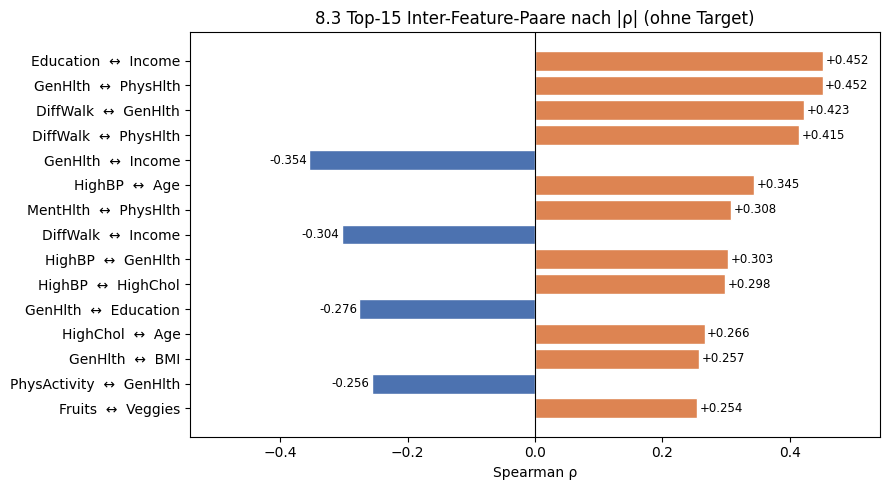

Top-15 Inter-Feature-Paare (Spearman ρ):
   Feature A Feature B         ρ      |ρ|
   Education    Income  0.451978 0.451978
     GenHlth  PhysHlth  0.451847 0.451847
    DiffWalk   GenHlth  0.422791 0.422791
    DiffWalk  PhysHlth  0.415022 0.415022
     GenHlth    Income -0.354253 0.354253
      HighBP       Age  0.344535 0.344535
    MentHlth  PhysHlth  0.308050 0.308050
    DiffWalk    Income -0.303711 0.303711
      HighBP   GenHlth  0.303300 0.303300
      HighBP  HighChol  0.298199 0.298199
     GenHlth Education -0.275783 0.275783
    HighChol       Age  0.266355 0.266355
     GenHlth       BMI  0.257342 0.257342
PhysActivity   GenHlth -0.256241 0.256241
      Fruits   Veggies  0.254342 0.254342


In [16]:
# --- 8.3 Top-15 Inter-Feature-Paare (ohne Target) ---
feature_corr = corr_df.drop("Diabetes_binary", axis=0).drop("Diabetes_binary", axis=1)

# Flache obere Dreiecksmatrix (ohne Diagonale)
upper_idx = np.triu_indices_from(feature_corr.values, k=1)
pairs = pd.DataFrame({
    "Feature A": feature_corr.columns[upper_idx[0]],
    "Feature B": feature_corr.columns[upper_idx[1]],
    "ρ":         feature_corr.values[upper_idx],
}).assign(**{"|ρ|": lambda d: d["ρ"].abs()}).sort_values("|ρ|", ascending=False)

top_pairs = pairs.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
pair_labels = [f"{a}  ↔  {b}" for a, b in zip(top_pairs["Feature A"], top_pairs["Feature B"])]
colors = ["#DD8452" if r > 0 else "#4C72B0" for r in top_pairs["ρ"]]
bars = ax.barh(pair_labels[::-1], top_pairs["ρ"].values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, top_pairs["ρ"].values[::-1]):
    xpos = val + (0.004 if val >= 0 else -0.004)
    ha = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2, f"{val:+.3f}", va="center", ha=ha, fontsize=8.5)
ax.set_xlabel("Spearman ρ")
ax.set_title("8.3 Top-15 Inter-Feature-Paare nach |ρ| (ohne Target)", fontsize=12)
lim = top_pairs["|ρ|"].max() + 0.09
ax.set_xlim(-lim, lim)
plt.tight_layout()
plt.show()

print("Top-15 Inter-Feature-Paare (Spearman ρ):")
print(top_pairs[["Feature A", "Feature B", "ρ", "|ρ|"]].to_string(index=False))

**Interpretation:**

**Keine schwere Multikollinearität, aber moderater Strukturanteil.** Die stärkste
Inter-Feature-Korrelation liegt bei ρ = 0.452 (Education ↔ Income; GenHlth ↔ PhysHlth) —
deutlich unterhalb der kritischen Schwelle von |ρ| = 0.7, ab der einzelne Features für
Logistic Regression problematisch werden. Allerdings fallen **acht der fünfzehn Paare** in
den Bereich |ρ| = 0.25–0.45, was kumulativ zu instabilen Koeffizienten führen kann.
**Ein VIF-Check in Phase 3 ist deshalb obligatorisch** vor dem Training der
Logistic-Regression-Baseline. Tree-basierte Modelle (XGBoost, Random Forest) sind von
diesem Strukturanteil nicht betroffen.

**Drei strukturelle Cluster werden sichtbar:**

*Physical-Health-Cluster* (4 der Top-7): GenHlth ↔ PhysHlth (ρ = 0.45),
DiffWalk ↔ GenHlth (ρ = 0.42), DiffWalk ↔ PhysHlth (ρ = 0.42), MentHlth ↔ PhysHlth
(ρ = 0.31). Vier Features messen körperliche und subjektive Gesundheitseinschränkungen
aus überlappenden Perspektiven. Da diese vier Features gleichzeitig zu den stärksten
Target-Prädiktoren gehören (siehe 8.2), ist dieser Cluster der **wichtigste
Composite-Kandidat**: ein „Physical-Health-Score" aus GenHlth, PhysHlth und DiffWalk
würde die Information bündeln und Multikollinearität in der LogReg reduzieren.

*Sozioökonomischer Cluster*: Education ↔ Income (ρ = 0.45), GenHlth ↔ Income (ρ = −0.35),
DiffWalk ↔ Income (ρ = −0.30), GenHlth ↔ Education (ρ = −0.28). Die starke Bindung
zwischen Education und Income ist erwartbar (Bildungsabschluss determiniert
Einkommen). Auffällig ist der **negative Spillover** auf Gesundheitsvariablen: höhere
Bildung/Einkommen gehen mit besserer Gesundheit einher — ein sozialer Gradient, der
in der epidemiologischen Diabetes-Literatur etabliert ist (Agardh et al., 2011).
Ein sozioökonomischer Composite (Income + Education) wird in Phase 3 geprüft.

*Cardiovascular-Cluster*: HighBP ↔ Age (ρ = 0.35), HighBP ↔ HighChol (ρ = 0.30),
HighChol ↔ Age (ρ = 0.27), HighBP ↔ GenHlth (ρ = 0.30). Bluthochdruck, hohes
Cholesterin und Alter treten gemeinsam auf — biologisch erwartet, da kardiovaskuläre
Risiken mit dem Alter akkumulieren. Da HeartDiseaseorAttack und Stroke hier knapp
außerhalb der Top-15 liegen, deren Verbindung in 8.1 aber sichtbar war (ρ = 0.20–0.21),
bleibt der Cardiovascular-Composite (HighBP, HighChol, HeartDiseaseorAttack, Stroke)
ein berechtigter Kandidat.

**Weitere Befunde:**

- **PhysActivity ↔ GenHlth (ρ = −0.26)**: Wer körperlich aktiv ist, berichtet bessere
  Gesundheit. Das bestätigt PhysActivity als zumindest schwach informativen Verhaltensprädiktor,
  auch wenn es im Target-Ranking (8.2) nicht erscheint.
- **Fruits ↔ Veggies (ρ = 0.25)**: Die beiden Ernährungs-Features bewegen sich gemeinsam,
  wie zu erwarten. Beide korrelieren nur schwach mit dem Target, eignen sich aber als
  Bausteine eines Lifestyle-Composites.
- **MentHlth ↔ PhysHlth (ρ = 0.31)**: Psychische und körperliche Gesundheit hängen
  zusammen. Trotz dieser inhaltlich starken Verbindung korreliert MentHlth selbst kaum
  mit Diabetes (ρ = 0.04, siehe 8.2). Das stützt die Hypothese aus 8.1, dass MentHlth
  durch Zero-Inflation gedämpft wird und in Phase 3 als Hurdle behandelt werden sollte.

**Konsequenzen für Phase 3:**
- **Composite-Kandidat 1 — Physical-Health-Score**: GenHlth, PhysHlth, DiffWalk
- **Composite-Kandidat 2 — Cardiovascular-Score**: HighBP, HighChol, HeartDiseaseorAttack, Stroke
- **Composite-Kandidat 3 — Sozioökonomischer Score**: Income + Education
- **Composite-Kandidat 4 — Lifestyle-Score** (optional): PhysActivity, Fruits, Veggies,
  invertiert Smoker und HvyAlcoholConsump
- **VIF-Check** vor LogReg obligatorisch; Schwellwert VIF > 5 als Aktionsgrenze.
- Composite-Validierung über Ablation in Phase 4: PR-AUC mit vs. ohne Composite vergleichen.

## 9. Outlier-Untersuchung

Ein Outlier ist ein Wert, der weit vom Rest entfernt liegt. Wir unterscheiden zwei
Typen: Datenfehler (BMI = 98 ist biologisch implausibel, vermutlich Eingabefehler)
und seltene, aber echte Fälle (BMI = 60 ist möglich, aber rar). Beide stören Modelle —
Datenfehler weil sie Müll sind, echte Extremwerte weil sie Statistiken und
Regressionskoeffizienten verzerren können.

In Phase 3 muss für jedes numerische Feature eine Entscheidung getroffen werden:
unverändert lassen, cappen, droppen oder transformieren. Diese Entscheidung darf
nicht aus dem Bauch kommen. Wir liefern hier die quantitative Begründung.

**Welche Features sind relevant?**

Klassische Outlier-Analyse setzt eine intervallskalierte numerische Variable voraus.
Für die anderen Feature-Typen ist sie nicht anwendbar oder bedeutet etwas anderes:

| Feature-Typ | Outlier-Analyse? | Relevante Diagnose |
|---|---|---|
| Binär | nein — nur 0 oder 1 | Near-Constancy (siehe 6.1) |
| Ordinal | nein — bounded Kategorien | Schiefe / Deckeneffekte (si

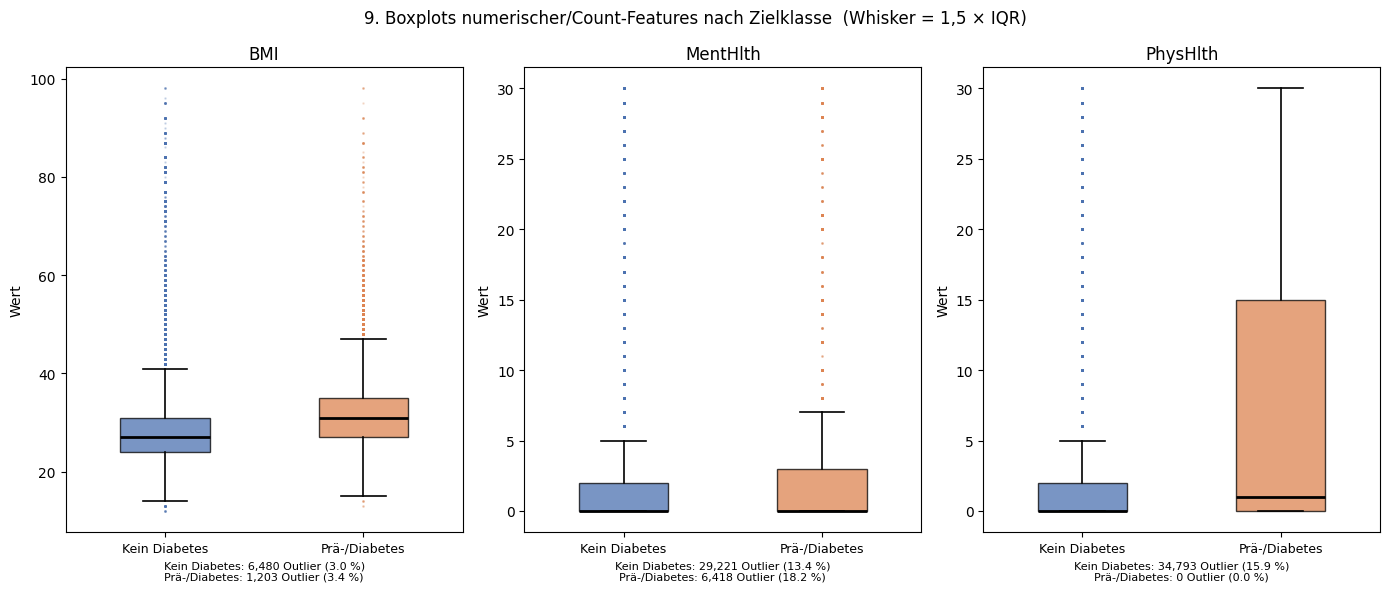

Feature       Klasse             Median      IQR   Whisker↑   Outlier       %
------------------------------------------------------------------------
BMI           Kein Diabetes        27.0      7.0       41.5     6,480   2.97%
BMI           Prä-/Diabetes        31.0      8.0       47.0     1,203   3.40%
MentHlth      Kein Diabetes         0.0      2.0        5.0    29,221  13.38%
MentHlth      Prä-/Diabetes         0.0      3.0        7.5     6,418  18.16%
PhysHlth      Kein Diabetes         0.0      2.0        5.0    34,793  15.94%
PhysHlth      Prä-/Diabetes         1.0     15.0       37.5         0   0.00%


In [17]:
outlier_cols  = NUMERIC_COLS + COUNT_COLS   # ["BMI", "MentHlth", "PhysHlth"]
palette       = {0: "#4C72B0", 1: "#DD8452"}
class_labels  = {0: "Kein Diabetes", 1: "Prä-/Diabetes"}

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for ax, col in zip(axes, outlier_cols):
    data_by_class = [df.loc[df["Diabetes_binary"] == c, col].values for c in [0, 1]]

    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker=".", markersize=1.8, alpha=0.2, linestyle="none"),
    )
    for patch, cls in zip(bp["boxes"], [0, 1]):
        patch.set_facecolor(palette[cls])
        patch.set_alpha(0.75)
    for flier, cls in zip(bp["fliers"], [0, 1]):
        flier.set_markerfacecolor(palette[cls])
        flier.set_markeredgecolor(palette[cls])

    ax.set_xticks([1, 2])
    ax.set_xticklabels([class_labels[0], class_labels[1]], fontsize=9)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Wert")

    # Outlier-Zählungen direkt unterhalb der x-Achse als xlabel
    lines = []
    for cls, dat in zip([0, 1], data_by_class):
        q1, q3 = np.percentile(dat, [25, 75])
        iqr = q3 - q1
        n_out = ((dat > q3 + 1.5 * iqr) | (dat < q1 - 1.5 * iqr)).sum()
        lines.append(f"{class_labels[cls]}: {n_out:,} Outlier ({n_out/len(dat)*100:.1f} %)")
    ax.set_xlabel("\n".join(lines), fontsize=8)

plt.suptitle("9. Boxplots numerischer/Count-Features nach Zielklasse  (Whisker = 1,5 × IQR)", fontsize=12)
plt.tight_layout()
plt.show()

# Kennzahlentabelle
print(f"{'Feature':<12}  {'Klasse':<16}  {'Median':>7}  {'IQR':>7}  {'Whisker↑':>9}  {'Outlier':>8}  {'%':>6}")
print("-" * 72)
for col in outlier_cols:
    for cls in [0, 1]:
        dat = df.loc[df["Diabetes_binary"] == cls, col].values
        q1, q3 = np.percentile(dat, [25, 75])
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        n_out = ((dat > upper) | (dat < q1 - 1.5 * iqr)).sum()
        print(f"{col:<12}  {class_labels[cls]:<16}  {np.median(dat):>7.1f}  {iqr:>7.1f}  "
              f"{upper:>9.1f}  {n_out:>8,}  {n_out/len(dat)*100:>5.2f}%")

**Interpretation:**

**BMI — moderater Klassen-Shift, ähnliche Outlier-Raten**

Median verschiebt sich von 27 (Kein Diabetes) auf 31 (Prä-/Diabetes), IQR bleibt
nahezu identisch (7 vs. 8). Die Outlier-Raten sind in beiden Klassen vergleichbar
(3,0 % vs. 3,4 %). Das bedeutet: BMI-Extremwerte sind **nicht klassendiskriminierend**,
sondern allgemeines Rauschen oder Erfassungsfehler — sie verteilen sich proportional
auf beide Klassen. Konsequenz für Phase 3: ein einheitliches Capping (z. B. P1/P99)
verliert keine klassenspezifische Information und ist methodisch unbedenklich.
Die genaue Wahl der Schwelle wird in 9.2 begründet.

**MentHlth — IQR-Methode kollabiert auf Zero-Inflation**

Beide Klassen haben Median 0 und kleine IQRs (2 bzw. 3). Die Whisker liegen bei 5
bzw. 7,5, und alles darüber wird mechanisch als Outlier markiert — das sind 13,4 %
respektive 18,2 % der Daten. Diese Werte sind **keine echten Outlier**, sondern eine
mathematische Konsequenz der Zero-Inflation (69 % Nullen). Wenn die Box auf 0
kollabiert, wird schon ein moderater Wert (6 oder 8 schlechte Tage im Monat) als
„extrem" klassifiziert, obwohl er inhaltlich völlig plausibel ist. Das ist genau
das Versagensmuster, das wir methodisch erwartet haben.

Die Verteilung zeigt zusätzlich einen leichten Klassen-Shift (etwas mehr positive Werte
und etwas größerer IQR in der Diabetes-Gruppe), der jedoch durch die Zero-Inflation
gedämpft wird. Phase 3 wird MentHlth daher als Hurdle-Encoding behandeln, um diesen
gedämpften Effekt zu separieren.

**PhysHlth — der wichtigste Befund: Outlier sind klassenrelativ**

Hier zeigt sich das stärkste Ergebnis dieser Section. In der Kontrollgruppe ist die
Verteilung praktisch identisch zu MentHlth: Median 0, IQR 2, 15,9 % „Outlier".
In der Diabetes-Gruppe verändert sich das Bild komplett:

- Median verschiebt sich auf 1
- **IQR explodiert auf 15** (Q1 = 0, Q3 = 15)
- Whisker reicht bis 37,5 — oberhalb des Maximums von 30
- Folge: **0 IQR-Outlier**, obwohl Werte bis 30 vorkommen

Das bedeutet: dieselben Werte (z. B. 12 Tage schlechte körperliche Gesundheit) sind
in der Kontrollgruppe Outlier, in der Diabetes-Gruppe **typische Werte innerhalb der
Box**. Klassische Outlier-Entfernung würde hier systematisch das Signal zerstören,
das den Diabetes-Status diskriminiert.

Dieser Befund liefert die stärkste mögliche Begründung gegen jede Form von
Outlier-Entfernung bei den Count-Features — und gleichzeitig die stärkste Motivation
für ein Hurdle-Encoding in Phase 3, das die binäre Komponente (überhaupt schlechte
Tage ja/nein) und die kontinuierliche Komponente (wie viele) sauber separiert.

**Konsequenzen für Phase 3:**

- **BMI**: Capping methodisch begründbar; konkrete Schwelle in 9.2 festgelegt
- **MentHlth & PhysHlth**: keine Outlier-Entfernung; stattdessen Hurdle-Encoding
  (`_any`: 0/1 — gab es überhaupt schlechte Tage; `_days`: Anzahl wenn > 0)
- Die klassenrelative Natur von Outliern bei PhysHlth ist ein eigenständig
  berichtbarer Befund für die Thesis-Diskussion (Diabetes-Status ist mit einer
  fundamental anderen PhysHlth-Verteilung verbunden, nicht nur einem Mittelwert-Shift)

### 9.2 BMI — Methodenvergleich klassischer Outlier-Definitionen

Aus 9.1 ist bekannt: BMI ist das einzige numerische Feature, bei dem klassische
Outlier-Methoden inhaltlich sinnvoll anwendbar sind. Welche der drei Standard-Methoden
wir in Phase 3 verwenden, hängt davon ab, wie gut sie zur Verteilungsform passen.
BMI ist rechtsschief (Median 27, Maximum 98) — Methoden mit Symmetrie- oder
Normalitätsannahme sind systematisch problematisch.

Wir vergleichen drei Methoden auf derselben Verteilung:

- **IQR (Tukey, 1977):** Grenzen bei Q1 − 1,5·IQR und Q3 + 1,5·IQR. Symmetrisch um
  die Box, aber bei rechtsschiefen Daten asymmetrisch in der Wirkung.
- **3σ:** Grenzen bei μ ± 3σ. Annahme Normalverteilung; bei rechtsschiefen Daten
  zusätzlich selbstreferenziell — die Outlier selbst inflationieren σ und maskieren
  sich dadurch teilweise.
- **Perzentil (P1/P99):** Verteilungsfrei, robust gegen Schiefe und Extremwerte;
  die Schwelle ist eine Konvention, kein Modellergebnis.

Die linke Abbildung zeigt den BMI-Boxplot mit allen drei oberen Schwellen
eingezeichnet. Die rechte Tabelle quantifiziert, wie viele Werte jede Methode als
Outlier markiert. Die View ist bei P99,8 abgeschnitten, damit die Schwellen sichtbar
bleiben; die extremen BMI-Werte (> 75) sind weiterhin im Datensatz vorhanden.

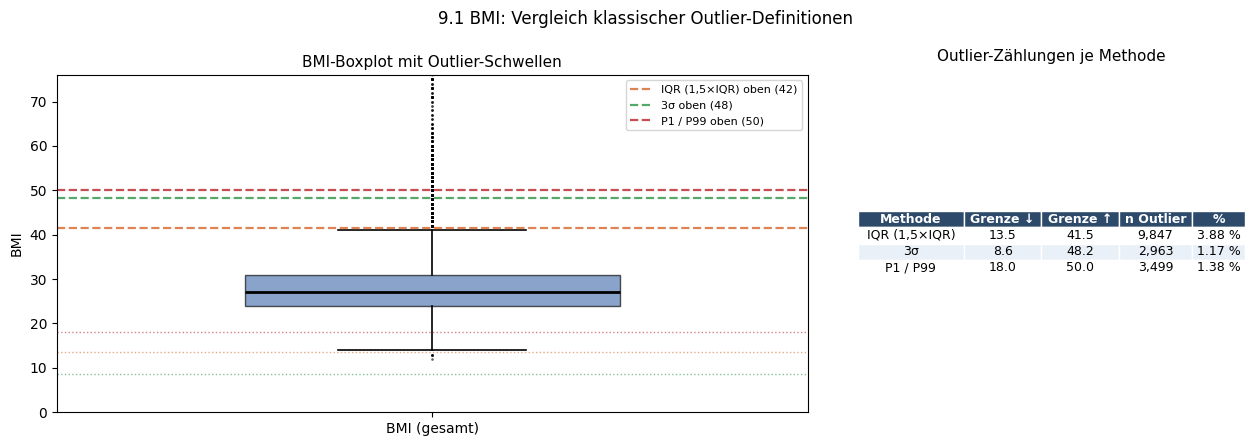

In [18]:
bmi = df["BMI"].values
n   = len(bmi)

# --- Schwellen berechnen ---
q1, q3   = np.percentile(bmi, [25, 75])
iqr      = q3 - q1
mu, sigma = bmi.mean(), bmi.std()
p1, p99  = np.percentile(bmi, [1, 99])

methods = {
    "IQR (1,5×IQR)": (q1 - 1.5 * iqr, q3 + 1.5 * iqr),
    "3σ":            (mu - 3 * sigma,   mu + 3 * sigma),
    "P1 / P99":      (p1,               p99),
}
colors_line = {"IQR (1,5×IQR)": "#DD8452", "3σ": "#55A868", "P1 / P99": "#C44E52"}

fig, (ax_box, ax_tab) = plt.subplots(
    1, 2, figsize=(13, 4.5),
    gridspec_kw={"width_ratios": [2, 1]},
)

# --- Boxplot ---
bp = ax_box.boxplot(
    bmi,
    vert=True,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker=".", markersize=1.5, alpha=0.15, color="#4C72B0"),
)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][0].set_alpha(0.65)

y_max = np.percentile(bmi, 99.8)   # clip view so lines are visible
ax_box.set_ylim(0, y_max + 3)

for name, (lo, hi) in methods.items():
    col = colors_line[name]
    ax_box.axhline(hi, color=col, linewidth=1.6, linestyle="--", label=f"{name} oben ({hi:.0f})")
    if lo > 0:
        ax_box.axhline(lo, color=col, linewidth=1.0, linestyle=":", alpha=0.7)

ax_box.set_xticks([1])
ax_box.set_xticklabels(["BMI (gesamt)"])
ax_box.set_ylabel("BMI")
ax_box.set_title("BMI-Boxplot mit Outlier-Schwellen", fontsize=11)
ax_box.legend(fontsize=8, loc="upper right")

# --- Tabelle ---
rows, col_labels = [], ["Methode", "Grenze ↓", "Grenze ↑", "n Outlier", "%"]
for name, (lo, hi) in methods.items():
    n_out = ((bmi > hi) | (bmi < lo)).sum()
    rows.append([name, f"{lo:.1f}", f"{hi:.1f}", f"{n_out:,}", f"{n_out/n*100:.2f} %"])

ax_tab.axis("off")
tbl = ax_tab.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(list(range(len(col_labels))))
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2d4a6b")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#eaf0f8")
    cell.set_edgecolor("white")

ax_tab.set_title("Outlier-Zählungen je Methode", fontsize=11, pad=10)

plt.suptitle("9.1 BMI: Vergleich klassischer Outlier-Definitionen", fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**

Die drei Methoden liefern deutlich unterschiedliche Ergebnisse — von 1,17 % bis
3,88 % markierter Outlier. Das zeigt: die Wahl der Methode ist keine Formalität,
sondern hat substanziellen Einfluss darauf, welche Datenpunkte in Phase 3 behandelt
werden.

**IQR (3,88 %, 9 847 Outlier) — zu aggressiv für rechtsschiefe Daten**

Die obere IQR-Grenze liegt bei 41,5 — also unterhalb der klinisch klar plausiblen
Adipositas-Grad-III-Schwelle von BMI 40 (WHO). Werte zwischen 41 und 50 sind
biologisch real und in der US-amerikanischen Erwachsenenbevölkerung mit substanzieller
Häufigkeit vertreten; sie als „Outlier" zu klassifizieren ist methodisch fragwürdig.
Der Befund bestätigt die theoretische Erwartung: IQR ist symmetrisch um die Box,
aber bei rechtsschiefen Daten muss eine sinnvolle Outlier-Definition asymmetrisch
sein. **Verworfen.**

**3σ (1,17 %, 2 963 Outlier) — durch Verteilungsannahme und Selbstreferenz verzerrt**

Die obere 3σ-Grenze liegt bei 48,2 und damit höher als die IQR-Grenze. Das wirkt
zunächst angemessener, hat aber zwei Probleme. Erstens setzt 3σ Normalverteilung
voraus — bei sichtbar schiefen Daten ist diese Annahme verletzt. Zweitens sind μ
und σ selbst durch Extremwerte gezogen: BMI = 98 erhöht σ und damit auch die
Outlier-Schwelle. Die wenigen Outlier sind also nicht ein Zeichen für saubere
Daten, sondern für eine Methode, die ihre eigenen Outlier teilweise verbirgt.
Die untere Grenze (8,6) liegt unterhalb des physiologischen Minimums (BMI ~12 ist
extrem niedrig, aber dokumentiert) und markiert in dieser Verteilung keine Werte.
**Verworfen.**

**P1 / P99 (1,38 %, 3 499 Outlier) — methodisch sauberste Wahl**

Die Perzentil-Methode liefert Grenzen bei 18 und 50. Diese Werte sind unabhängig
von Schiefe und Verteilungsform berechnet und stimmen zufällig mit etablierten
klinischen BMI-Kategorien überein: BMI < 18,5 = Untergewicht (WHO), BMI ≥ 50 =
Super-Adipositas. Die Methode markiert symmetrisch je 1 % der Daten unten und
oben — eine bewusste, dokumentierbare Konvention statt einer impliziten
Verteilungsannahme.

**Entscheidung für Phase 3**

Capping bei BMI ∈ [18, 50] mittels Perzentil-Methode (P1/P99). Methodische
Begründung:

1. Verteilungsfreiheit — keine Annahme über Schiefe oder Normalität
2. Robustheit — Perzentile sind selbst nicht von Extremwerten gezogen
3. Klinische Plausibilität — die resultierenden Grenzen entsprechen WHO-Schwellen
4. Konservative Aggressivität — 1,38 % Capping verliert minimal Information,
   eliminiert aber dokumentierte Implausibilitäten (BMI = 98)

Die Operation in Phase 3 ist ein **Winsorizing**: Werte < 18 werden auf 18 gesetzt,
Werte > 50 auf 50. Es werden keine Zeilen entfernt — die Information „extremer
BMI" bleibt durch den Capping-Wert erhalten, ohne Modelle durch Einzelwerte zu
destabilisieren.

## 10. Zusammenfassung und Konsequenzen für die Datenaufbereitung

Die Data-Understanding-Phase zeigt, dass der Datensatz technisch sauber ist:
Es gibt keine fehlenden Werte, alle Variablen sind konsistent kodiert und das Target
ist binär.

Gleichzeitig ergeben sich aus der explorativen Analyse mehrere methodisch relevante
Punkte, die in der nächsten Phase systematisch geprüft und umgesetzt werden sollen.

Die Zielvariable ist stark ungleich verteilt: Nur ca. 13,9 % der Beobachtungen gehören
zur positiven Klasse. Deshalb sollte Accuracy nicht als Hauptmetrik verwendet werden.
Stattdessen wird in den folgenden Modellierungsphasen geprüft, wie gut sich die Modelle
insbesondere hinsichtlich PR-AUC und Recall der positiven Klasse verhalten.

Exakte Duplikate werden zunächst nicht entfernt, da sie bei einem grob kodierten
Survey-Datensatz erwartbar sind und nicht automatisch auf Datenfehler hinweisen.
Feature-Vektoren mit widersprüchlichen Labels deuten jedoch auf empirisches
Label-Rauschen hin. Dieser Befund wird für die spätere Interpretation der Modellleistung
berücksichtigt, insbesondere weil das Target eher den diagnostizierten Diabetesstatus
als den tatsächlichen Krankheitsstatus misst.

Die explorativen Analysen zeigen, dass GenHlth, HighBP, BMI, DiffWalk, HighChol und
Age besonders stark mit dem Target zusammenhängen. Diese Variablen werden daher in
den folgenden Phasen besonders beobachtet, etwa bei Feature Importance,
Permutation Importance oder SHAP-Auswertungen.

Die Korrelationsanalyse zeigt keine schwere Multikollinearität, aber mehrere inhaltlich
plausible Feature-Cluster, insbesondere kardiovaskuläre Gesundheit, körperliche
Gesundheit und sozioökonomischer Status. In Notebook 3 wird deshalb erprobt, ob
aus diesen Clustern sinnvolle Composite Features gebildet werden können. Ob diese
Features tatsächlich im finalen Modell bleiben, wird später empirisch über
Modellvergleich und Ablation geprüft.

Für BMI zeigt die Outlier-Analyse, dass extreme Werte vorhanden sind. In Notebook 3
wird daher ein Capping beziehungsweise Winsorizing auf Basis der zuvor bestimmten
Grenzen geprüft. Dabei sollen keine Zeilen entfernt werden, sondern nur extreme
BMI-Werte begrenzt werden.

MentHlth und PhysHlth werden nicht als klassische Outlier behandelt, da hohe Werte
inhaltlich relevante Informationen enthalten können. In Notebook 3 wird deshalb ein
Hurdle-Encoding erprobt, bei dem getrennt modelliert wird, ob überhaupt schlechte
Gesundheitstage berichtet wurden und wie viele Tage angegeben wurden.

Daraus ergeben sich für Notebook 3 folgende Arbeitsschritte:
Train-Test-Split, Prüfung von BMI-Capping, Erprobung von Hurdle-Encoding für
MentHlth und PhysHlth, Konstruktion und spätere Validierung möglicher Composite
Features, VIF-Check für die Logistic-Regression-Baseline sowie der Aufbau geeigneter
Preprocessing-Pipelines.